# Predictive maintenance

Follow the project from source data and historical features to failure prediction,
anomaly detection, SHAP explanations, and basic remaining-useful-life regression.
The saved plots and metrics are retained from the verified project run. One final
integration section checks the fitted models and key data boundaries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load and inspect the source data


In [2]:
machines = pd.read_csv("../data/PdM_machines.csv")


In [3]:
machines.head()


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [4]:
machines["model"].value_counts()


model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

In [5]:
machines.shape


(100, 3)

In [6]:
machines.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [7]:
machines.isnull().sum()


machineID    0
model        0
age          0
dtype: int64

In [8]:
machines.duplicated().sum()


np.int64(0)

In [9]:
telemetry = pd.read_csv("../data/PdM_telemetry.csv")


In [10]:
telemetry.head()


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [11]:
telemetry.shape


(876100, 6)

In [12]:
telemetry.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


In [13]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])


In [14]:
telemetry.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB


In [15]:
telemetry.isnull().sum()


datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

In [16]:
telemetry.duplicated().sum()


np.int64(0)

In [17]:
telemetry.describe()


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [18]:
telemetry["machineID"].nunique()


100

In [19]:
telemetry["machineID"].value_counts().sort_index()


machineID
1      8761
2      8761
3      8761
4      8761
5      8761
       ... 
96     8761
97     8761
98     8761
99     8761
100    8761
Name: count, Length: 100, dtype: int64

In [20]:
machine_1 = telemetry[telemetry["machineID"] == 1]
machine_1.head()


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


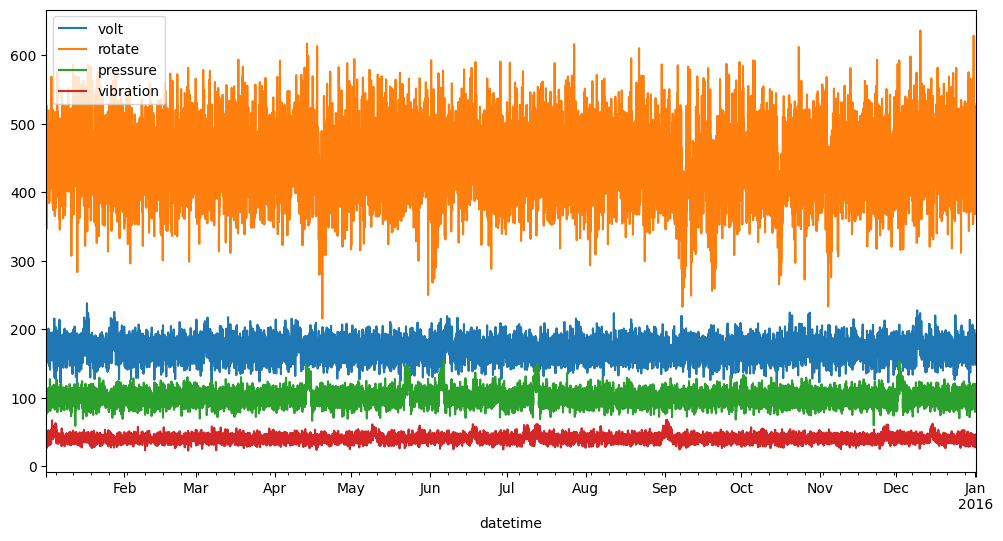

In [21]:
machine_1.plot(x="datetime", y=["volt", "rotate", "pressure", "vibration"], figsize=(12, 6))
plt.show()


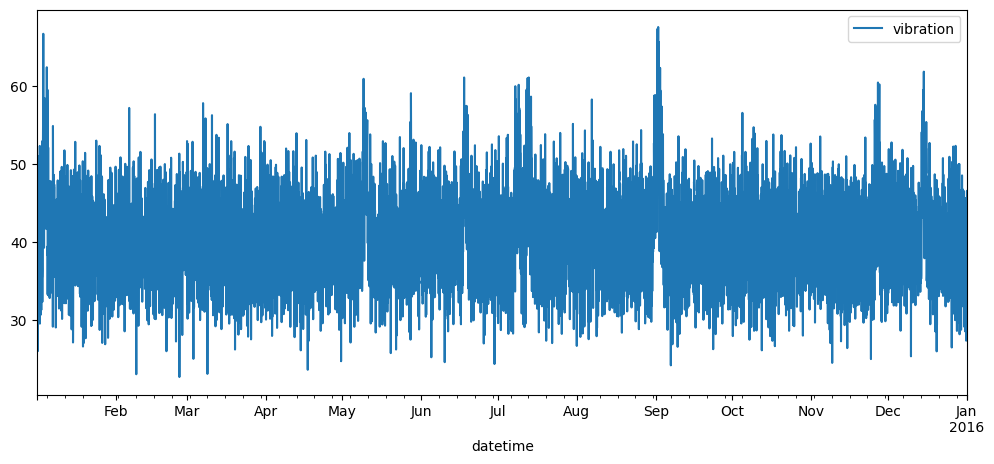

In [22]:
machine_1.plot(x="datetime", y="vibration", figsize=(12, 5))
plt.show()


In [23]:
machine_1["vibration"].agg(["mean", "max"])


mean    40.586309
max     67.633435
Name: vibration, dtype: float64

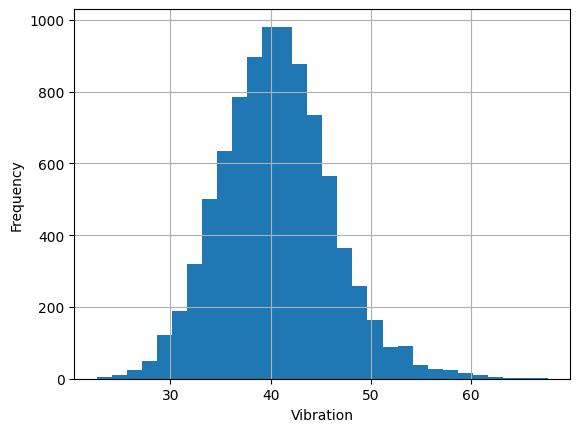

In [24]:
machine_1["vibration"].hist(bins=30)
plt.xlabel("Vibration")
plt.ylabel("Frequency")
plt.show()


In [25]:
machine_1["vibration"].describe()


count    8761.000000
mean       40.586309
std         5.542143
min        22.666865
25%        36.847203
50%        40.417442
75%        44.004311
max        67.633435
Name: vibration, dtype: float64

In [26]:
telemetry.columns


Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration'], dtype='object')

In [27]:
sensor_columns = ["volt", "rotate", "pressure", "vibration"]
telemetry[sensor_columns].corr()


,volt,rotate,pressure,vibration
volt,1.000000,-0.001511,0.001652,0.002390
rotate,-0.001511,1.000000,-0.000688,-0.003056
pressure,0.001652,-0.000688,1.000000,0.001395
vibration,0.002390,-0.003056,0.001395,1.000000


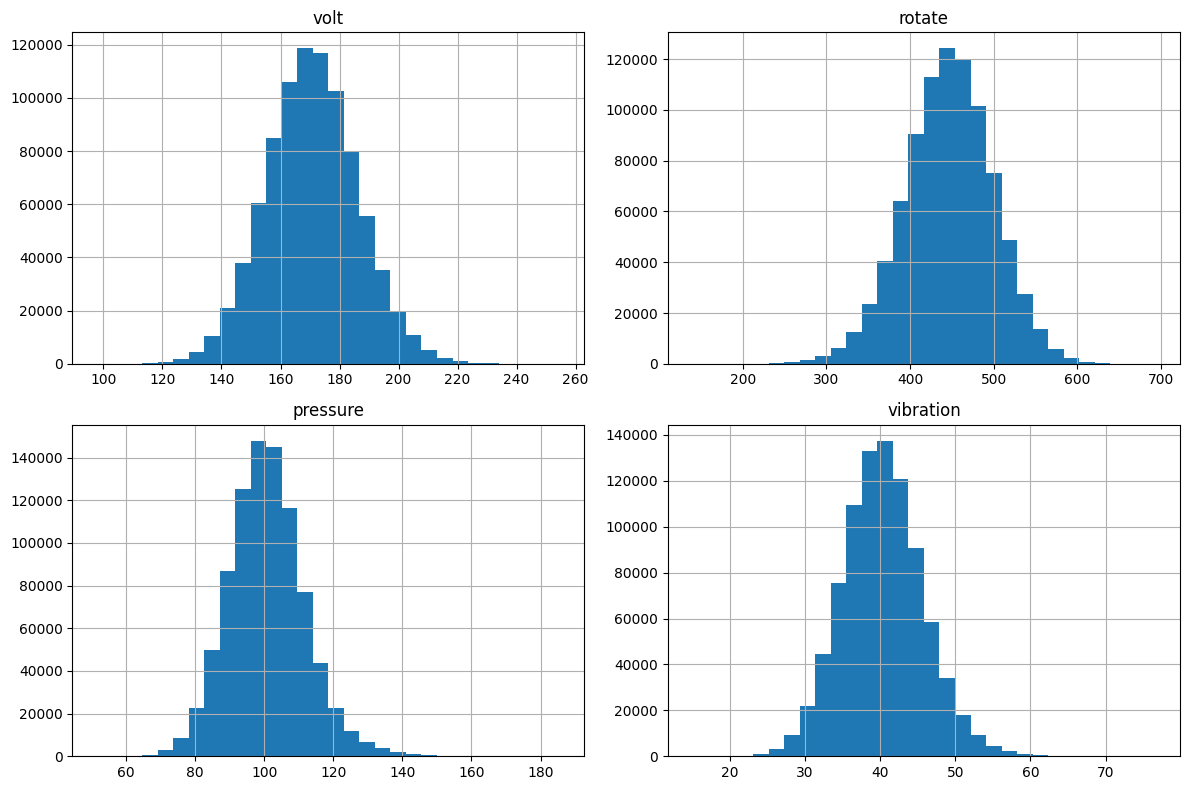

In [28]:
telemetry[sensor_columns].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


In [29]:
failures = pd.read_csv("../data/PdM_failures.csv")

print("Shape:", failures.shape)

print("\nColumns:")
print(failures.columns)

print("\nInfo:")
failures.info()

print("\nFirst 5 rows:")
display(failures.head())

print("\nNull values:")
print(failures.isnull().sum())

print("\nDuplicate rows:")
print(failures.duplicated().sum())

print("\nFailure types:")
print(failures["failure"].value_counts())

print("\nMachines with failures:")
print(failures["machineID"].nunique())


Shape: (761, 3)

Columns:
Index(['datetime', 'machineID', 'failure'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB

First 5 rows:


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
failure      0
dtype: int64

Duplicate rows:
0

Failure types:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Machines with failures:
98


In [30]:
failures["datetime"] = pd.to_datetime(failures["datetime"])

failures = failures.sort_values(by=["machineID", "datetime"]).reset_index(drop=True)

print(failures["datetime"].dtype)

display(failures.head(10))


datetime64[ns]


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4
5,2015-10-17 06:00:00,1,comp2
6,2015-12-16 06:00:00,1,comp4
7,2015-03-19 06:00:00,2,comp1
8,2015-03-19 06:00:00,2,comp2
9,2015-04-18 06:00:00,2,comp2


In [31]:
errors = pd.read_csv("../data/PdM_errors.csv")

print("Shape:", errors.shape)

print("\nColumns:")
print(errors.columns)

print("\nFirst 5 rows:")
display(errors.head())

print("\nNull values:")
print(errors.isnull().sum())

print("\nDuplicate rows:")
print(errors.duplicated().sum())

print("\nUnique machines with errors:")
print(errors["machineID"].nunique())

print("\nError types:")
print(errors["errorID"].value_counts())

print("\nDatetime datatype:")
print(errors["datetime"].dtype)


Shape: (3919, 3)

Columns:
Index(['datetime', 'machineID', 'errorID'], dtype='object')

First 5 rows:


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4



Null values:
datetime     0
machineID    0
errorID      0
dtype: int64

Duplicate rows:
0

Unique machines with errors:
100

Error types:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

Datetime datatype:
object


In [32]:
errors["datetime"] = pd.to_datetime(errors["datetime"])

errors = errors.sort_values(by=["machineID", "datetime"]).reset_index(drop=True)

print(errors["datetime"].dtype)

display(errors.head(10))


datetime64[ns]


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4
5,2015-01-25 15:00:00,1,error4
6,2015-01-27 04:00:00,1,error1
7,2015-03-03 22:00:00,1,error2
8,2015-03-05 06:00:00,1,error1
9,2015-03-20 18:00:00,1,error1


In [33]:
maint = pd.read_csv("../data/PdM_maint.csv")

print("Shape:", maint.shape)

print("\nColumns:")
print(maint.columns)

print("\nFirst 5 rows:")
display(maint.head())

print("\nNull values:")
print(maint.isnull().sum())

print("\nDuplicate rows:")
print(maint.duplicated().sum())

print("\nUnique machines:")
print(maint["machineID"].nunique())

print("\nMaintenance types:")
print(maint["comp"].value_counts())

print("\nDatetime datatype:")
print(maint["datetime"].dtype)


Shape: (3286, 3)

Columns:
Index(['datetime', 'machineID', 'comp'], dtype='object')

First 5 rows:


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
comp         0
dtype: int64

Duplicate rows:
0

Unique machines:
100

Maintenance types:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

Datetime datatype:
object


In [34]:
maint["datetime"] = pd.to_datetime(maint["datetime"])

maint = maint.sort_values(by=["machineID", "datetime"]).reset_index(drop=True)

print(maint["datetime"].dtype)

display(maint.head(10))


datetime64[ns]


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4
5,2015-01-05 06:00:00,1,comp1
6,2015-01-20 06:00:00,1,comp3
7,2015-01-20 06:00:00,1,comp1
8,2015-02-04 06:00:00,1,comp4
9,2015-02-04 06:00:00,1,comp3


In [35]:
print(machines.columns)

display(machines.head())

print("\nMachine models:")
print(machines["model"].value_counts())

print("\nMachine age statistics:")
print(machines["age"].describe())


Index(['machineID', 'model', 'age'], dtype='object')


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2



Machine models:
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

Machine age statistics:
count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64


In [36]:
telemetry = telemetry.merge(
    machines[["machineID", "age"]], on="machineID", how="left", validate="many_to_one"
)

telemetry.head()


,datetime,machineID,volt,rotate,pressure,vibration,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18


## Combine readings and event history

Count recent errors, calculate time since maintenance, and create the next-24-hour
failure label. Work with each machine's sorted event times using NumPy searches.


In [37]:
# Work on a copy; the existing age merge is reused.
df = telemetry.copy()
if "age" not in df.columns:
    df = df.merge(
        machines[["machineID", "age"]], on="machineID", how="left", validate="many_to_one"
    )

# Process whole arrays per machine, rather than looping over telemetry rows.
error_counts = np.zeros(len(df), dtype=int)
maintenance_hours = np.full(len(df), np.nan)
failure_labels = np.zeros(len(df), dtype=int)
window = np.timedelta64(24, "h")

for machine_id, positions in df.groupby("machineID").indices.items():
    times = df.iloc[positions]["datetime"].to_numpy(dtype="datetime64[ns]")
    error_times = errors.loc[errors["machineID"] == machine_id, "datetime"].to_numpy(
        dtype="datetime64[ns]"
    )
    maintenance_times = maint.loc[maint["machineID"] == machine_id, "datetime"].to_numpy(
        dtype="datetime64[ns]"
    )
    failure_times = failures.loc[failures["machineID"] == machine_id, "datetime"].to_numpy(
        dtype="datetime64[ns]"
    )

    # Count every error in (time - 24 hours, time], including simultaneous errors.
    start = np.searchsorted(error_times, times - window, side="right")
    end = np.searchsorted(error_times, times, side="right")
    error_counts[positions] = end - start

    # The last maintenance at or before the reading; no history stays NaN.
    previous = np.searchsorted(maintenance_times, times, side="right") - 1
    has_maintenance = previous >= 0
    last_maintenance = maintenance_times[previous[has_maintenance]]
    maintenance_hours[positions[has_maintenance]] = (
        times[has_maintenance] - last_maintenance
    ) / np.timedelta64(1, "h")

    # Look forward only for the target: time < failure <= time + 24 hours.
    following = np.searchsorted(failure_times, times, side="right")
    has_future_failure = following < len(failure_times)
    next_failure = failure_times[following[has_future_failure]]
    failure_labels[positions[has_future_failure]] = (
        next_failure <= times[has_future_failure] + window
    ).astype(int)

df["errors_last_24h"] = error_counts
df["hours_since_last_maintenance"] = maintenance_hours
df["failure_next_24h"] = failure_labels


In [38]:
# Inspect the integrated data before building historical features.
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nNull values:")
print(df.isnull().sum())
print("\nFailure target counts:")
print(df["failure_next_24h"].value_counts().sort_index())
print("\nHistorical feature statistics:")
display(df[["errors_last_24h", "hours_since_last_maintenance"]].describe())


Shape: (876100, 10)
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'age', 'errors_last_24h', 'hours_since_last_maintenance', 'failure_next_24h']


,datetime,machineID,volt,rotate,pressure,vibration,age,errors_last_24h,hours_since_last_maintenance,failure_next_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,456.0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,457.0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,458.0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,459.0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,460.0,0



Null values:
datetime                        0
machineID                       0
volt                            0
rotate                          0
pressure                        0
vibration                       0
age                             0
errors_last_24h                 0
hours_since_last_maintenance    0
failure_next_24h                0
dtype: int64

Failure target counts:
failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

Historical feature statistics:


,errors_last_24h,hours_since_last_maintenance
count,876100.000000,876100.000000
mean,0.107253,263.621687
std,0.353272,322.139335
min,0.000000,0.000000
25%,0.000000,102.000000
50%,0.000000,205.000000
75%,0.000000,309.000000
max,4.000000,4079.000000


## Build historical features

The 24-hour statistics include the current reading. Six-hour changes compare
readings within the same machine. Keep chronological, hourly data for these windows.


In [39]:
# Row-based rolling/shift features require chronological, hourly machine history.
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
if df["datetime"].isna().any() or df.duplicated(["machineID", "datetime"]).any():
    raise ValueError("Telemetry requires unique, non-missing machine timestamps.")
if not df.groupby("machineID")["datetime"].diff().dropna().eq(pd.Timedelta(hours=1)).all():
    raise ValueError("The trained 24-row/6-row features require hourly telemetry.")

# Include the current reading and up to 23 earlier readings.
vibration_rolling_mean = (
    df.groupby("machineID")["vibration"].rolling(window=24, min_periods=1).mean()
)
df["vibration_24h_mean"] = vibration_rolling_mean.reset_index(level=0, drop=True)


In [40]:
display(df[["machineID", "datetime", "vibration", "vibration_24h_mean"]].head(30))


,machineID,datetime,vibration,vibration_24h_mean
0,1,2015-01-01 06:00:00,45.087686,45.087686
1,1,2015-01-01 07:00:00,43.413973,44.250829
2,1,2015-01-01 08:00:00,34.178847,40.893502
3,1,2015-01-01 09:00:00,41.122144,40.950662
4,1,2015-01-01 10:00:00,25.990511,37.958632
5,1,2015-01-01 11:00:00,35.655017,37.574696
6,1,2015-01-01 12:00:00,42.753920,38.314585
7,1,2015-01-01 13:00:00,35.482009,37.960513
8,1,2015-01-01 14:00:00,45.482287,38.796266
9,1,2015-01-01 15:00:00,39.901735,38.906813


In [41]:
for sensor in ["volt", "rotate", "pressure"]:
    rolling_mean = df.groupby("machineID")[sensor].rolling(window=24, min_periods=1).mean()
    df[f"{sensor}_24h_mean"] = rolling_mean.reset_index(level=0, drop=True)

display(
    df[
        [
            "machineID",
            "datetime",
            "volt_24h_mean",
            "rotate_24h_mean",
            "pressure_24h_mean",
        ]
    ].head(30)
)


,machineID,datetime,volt_24h_mean,rotate_24h_mean,pressure_24h_mean
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935
1,1,2015-01-01 07:00:00,169.548538,410.625784,104.269230
2,1,2015-01-01 08:00:00,170.028993,449.533798,94.592122
3,1,2015-01-01 09:00:00,168.137453,423.687682,98.256232
4,1,2015-01-01 10:00:00,166.031967,426.025520,100.982315
5,1,2015-01-01 11:00:00,167.110779,426.741827,100.139769
6,1,2015-01-01 12:00:00,165.602958,437.074655,101.799186
7,1,2015-01-01 13:00:00,166.467935,433.643413,101.699423
8,1,2015-01-01 14:00:00,167.452001,429.755120,102.691083
9,1,2015-01-01 15:00:00,167.628643,432.864675,102.906797


In [42]:
# Pandas uses the same sample standard deviation as the original features.
for sensor in ["volt", "pressure", "rotate", "vibration"]:
    rolling_std = df.groupby("machineID")[sensor].rolling(window=24, min_periods=1).std()
    df[f"{sensor}_24h_std"] = rolling_std.reset_index(level=0, drop=True)


In [43]:
df["vibration_vs_24h_mean"] = df["vibration"] - df["vibration_24h_mean"]

df["rotate_vs_24h_mean"] = df["rotate"] - df["rotate_24h_mean"]

df["pressure_vs_24h_mean"] = df["pressure"] - df["pressure_24h_mean"]

df["volt_vs_24h_mean"] = df["volt"] - df["volt_24h_mean"]


In [44]:
# Shift within each machine so changes never cross machine boundaries.
for sensor in ["vibration", "rotate", "pressure", "volt"]:
    reading_six_hours_ago = df.groupby("machineID")[sensor].shift(6)
    df[f"{sensor}_6h_change"] = df[sensor] - reading_six_hours_ago


In [45]:
cols_to_check = [
    "volt_24h_mean",
    "rotate_24h_mean",
    "pressure_24h_mean",
    "vibration_24h_mean",
    "volt_24h_std",
    "rotate_24h_std",
    "pressure_24h_std",
    "vibration_24h_std",
    "volt_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "vibration_6h_change",
]

print(df[cols_to_check].isnull().sum())


volt_24h_mean            0
rotate_24h_mean          0
pressure_24h_mean        0
vibration_24h_mean       0
volt_24h_std           100
rotate_24h_std         100
pressure_24h_std       100
vibration_24h_std      100
volt_6h_change         600
rotate_6h_change       600
pressure_6h_change     600
vibration_6h_change    600
dtype: int64


In [46]:
df.head()


,datetime,machineID,volt,rotate,pressure,vibration,age,errors_last_24h,hours_since_last_maintenance,failure_next_24h,...,rotate_24h_std,vibration_24h_std,vibration_vs_24h_mean,rotate_vs_24h_mean,pressure_vs_24h_mean,volt_vs_24h_mean,vibration_6h_change,rotate_6h_change,pressure_6h_change,volt_6h_change
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,456.0,0,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,457.0,0,...,11.141591,1.183494,-0.836857,-7.878294,-8.808705,-6.669315,NaN,NaN,NaN,NaN
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,458.0,0,...,67.849599,5.874970,-6.714655,77.816028,-19.354217,0.960910,NaN,NaN,NaN,NaN
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,459.0,0,...,75.770259,4.798255,0.171482,-77.538347,10.992330,-5.674620,NaN,NaN,NaN,NaN
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,460.0,0,...,65.826868,7.875828,-11.968121,9.351353,10.904333,-8.421945,NaN,NaN,NaN,NaN


In [47]:
df["hours_since_last_maintenance"].isnull().sum()


np.int64(0)

In [48]:
df["hours_since_last_maintenance"].isnull().mean() * 100


np.float64(0.0)

In [49]:
df.columns


Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'age', 'errors_last_24h', 'hours_since_last_maintenance',
       'failure_next_24h', 'vibration_24h_mean', 'volt_24h_mean',
       'rotate_24h_mean', 'pressure_24h_mean', 'volt_24h_std',
       'pressure_24h_std', 'rotate_24h_std', 'vibration_24h_std',
       'vibration_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean',
       'volt_vs_24h_mean', 'vibration_6h_change', 'rotate_6h_change',
       'pressure_6h_change', 'volt_6h_change'],
      dtype='object')

In [50]:
columns_to_fill = [
    "volt_24h_std",
    "pressure_24h_std",
    "rotate_24h_std",
    "vibration_24h_std",
    "vibration_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "volt_vs_24h_mean",
    "vibration_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "volt_6h_change",
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)


## Split by machine

Reuse the existing 70% training, 15% test, and 15% validation machine split.


In [51]:
# Split whole machines: 70% train, 15% test, 15% validation.
from sklearn.model_selection import train_test_split

# Count failure records, NOT positive rows in failure_next_24h.
# Include every machine in df; machines absent from failures get zero.
machine_split = df[["machineID"]].drop_duplicates()
machine_split = machine_split.sort_values("machineID").reset_index(drop=True)
machine_split["failure_count"] = (
    machine_split["machineID"].map(failures.groupby("machineID").size()).fillna(0).astype(int)
)

# Quantile bins keep equal failure counts in the same group.
# With the current data: low <= 6, medium 7-9, high >= 10.
machine_split["failure_group"], failure_bin_edges = pd.qcut(
    machine_split["failure_count"], q=3, labels=["low", "medium", "high"], retbins=True
)

train_machines, heldout_machines = train_test_split(
    machine_split, test_size=0.30, random_state=42, stratify=machine_split["failure_group"]
)
test_machines, validation_machines = train_test_split(
    heldout_machines, test_size=0.50, random_state=42, stratify=heldout_machines["failure_group"]
)

train_ids = set(train_machines["machineID"])
test_ids = set(test_machines["machineID"])
validation_ids = set(validation_machines["machineID"])

# Retain every row of an assigned machine in exactly one set.
train_df = df.loc[df["machineID"].isin(train_ids)].copy()
test_df = df.loc[df["machineID"].isin(test_ids)].copy()
validation_df = df.loc[df["machineID"].isin(validation_ids)].copy()

# Failure counts/groups are split metadata, not added as model features.
machine_split.loc[machine_split["machineID"].isin(train_ids), "split"] = "train"
machine_split.loc[machine_split["machineID"].isin(test_ids), "split"] = "test"
machine_split.loc[machine_split["machineID"].isin(validation_ids), "split"] = "validation"

split_summary = pd.DataFrame(
    {
        "machines": [len(train_ids), len(test_ids), len(validation_ids)],
        "rows": [len(train_df), len(test_df), len(validation_df)],
    },
    index=["train", "test", "validation"],
)
split_summary["machine_pct"] = 100 * split_summary["machines"] / len(machine_split)
split_summary["row_pct"] = 100 * split_summary["rows"] / len(df)
group_counts = pd.crosstab(machine_split["split"], machine_split["failure_group"]).reindex(
    index=split_summary.index, columns=["low", "medium", "high"], fill_value=0
)
group_percentages = group_counts.div(group_counts.sum(axis=1), axis=0) * 100
group_percentages.loc["overall"] = machine_split["failure_group"].value_counts(normalize=True) * 100

print("Failure-count quantile edges:", failure_bin_edges)
display(
    machine_split.groupby("failure_group", observed=True)["failure_count"].agg(
        ["min", "max", "count"]
    )
)
display(split_summary.round(2))
print("Machine counts per failure group:")
display(group_counts)
print("Failure-group percentages within each split:")
display(group_percentages.round(2))
# Ratios target machines; row percentages can differ if machine sizes differ.


Failure-count quantile edges: [ 0.  6.  9. 19.]


,min,max,count
failure_group,,,
low,0,6,40
medium,7,9,32
high,10,19,28


,machines,rows,machine_pct,row_pct
train,70,613270,70.0,70.0
test,15,131415,15.0,15.0
validation,15,131415,15.0,15.0


Machine counts per failure group:


failure_group,low,medium,high
train,28,22,20
test,6,5,4
validation,6,5,4


Failure-group percentages within each split:


failure_group,low,medium,high
train,40.0,31.43,28.57
test,40.0,33.33,26.67
validation,40.0,33.33,26.67
overall,40.0,32.00,28.00


In [52]:
df["failure_next_24h"].value_counts()


failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

## Failure prediction

Prepare the inputs, fit the training imputer, and compare weighted XGBoost with
training-only SMOTE plus XGBoost. The selected failure model uses threshold 0.60.


In [53]:
# Prepare numerical features using the existing machine-wise splits.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    average_precision_score,
)

target_column = "failure_next_24h"
excluded_columns = {
    "machineID",
    "datetime",
    target_column,
    "failure_count",
    "failure_group",
    "split",  # Split-only metadata.
}
# Frozen schema verified against the existing fitted SMOTE model and imputer.
feature_columns = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "age",
    "errors_last_24h",
    "hours_since_last_maintenance",
    "vibration_24h_mean",
    "volt_24h_mean",
    "rotate_24h_mean",
    "pressure_24h_mean",
    "volt_24h_std",
    "pressure_24h_std",
    "rotate_24h_std",
    "vibration_24h_std",
    "vibration_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "volt_vs_24h_mean",
    "vibration_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "volt_6h_change",
]

# Create the input matrices in the declared feature order.
X_train = train_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_validation = validation_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_test = test_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
# Keep the target separate from the inputs.
y_train = train_df[target_column].copy()
y_validation = validation_df[target_column].copy()
y_test = test_df[target_column].copy()

# Fit imputation only on training features; reuse it for both experiments.
# A training column with no observed values is consistently filled with zero.
feature_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_train = pd.DataFrame(
    feature_imputer.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index,
).astype("float32")
X_validation = pd.DataFrame(
    feature_imputer.transform(X_validation),
    columns=feature_columns,
    index=X_validation.index,
).astype("float32")
# X_test remains unprocessed until the selected-threshold evaluation cell.

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
baseline_xgb_params = dict(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=4,
    verbosity=0,
)


# Store threshold metrics silently; only confusion matrices are displayed below.
def threshold_results(y_true, probabilities, candidate_thresholds):
    pr_auc = average_precision_score(y_true, probabilities)
    records = []
    matrices = {}
    for threshold in candidate_thresholds:
        predictions = (probabilities >= threshold).astype(int)
        matrices[threshold] = confusion_matrix(y_true, predictions, labels=[0, 1])
        records.append(
            {
                "threshold": threshold,
                "precision": precision_score(y_true, predictions, zero_division=0),
                "recall": recall_score(y_true, predictions, zero_division=0),
                "f1": f1_score(y_true, predictions, zero_division=0),
                "accuracy": accuracy_score(y_true, predictions),
                "pr_auc": pr_auc,  # Average precision (not trapezoidal PR area).
            }
        )
    return pd.DataFrame(records).set_index("threshold"), matrices


In [54]:
# Experiment 1: train weighted XGBoost only on the original training set.
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count
weighted_xgb = XGBClassifier(**baseline_xgb_params, scale_pos_weight=scale_pos_weight)
weighted_xgb.fit(X_train, y_train)

# Validation only: keep all thresholds available for your decision.
weighted_validation_probabilities = weighted_xgb.predict_proba(X_validation)[:, 1]
weighted_validation_metrics, weighted_validation_confusion_matrices = threshold_results(
    y_validation,
    weighted_validation_probabilities,
    thresholds,
)
weighted_validation_pr_auc = average_precision_score(
    y_validation, weighted_validation_probabilities
)


In [55]:
# Experiment 2: SMOTE only on training data, followed by unweighted XGBoost.
# Standardize only for SMOTE's neighbour distances, then restore original units.
smote_scaler = StandardScaler()
X_train_for_smote = smote_scaler.fit_transform(X_train)
minority_count = int(y_train.value_counts().min())
if minority_count < 2:
    raise ValueError("SMOTE needs at least two minority-class training examples.")
smote_sampler = SMOTE(random_state=42, k_neighbors=min(5, minority_count - 1))
X_train_resampled_scaled, y_train_smote = smote_sampler.fit_resample(X_train_for_smote, y_train)
X_train_smote = pd.DataFrame(
    smote_scaler.inverse_transform(X_train_resampled_scaled),
    columns=feature_columns,
).astype("float32")
smote_class_distribution = pd.DataFrame(
    {
        "before_smote": y_train.value_counts().reindex([0, 1], fill_value=0),
        "after_smote": pd.Series(y_train_smote).value_counts().reindex([0, 1], fill_value=0),
    }
).rename(index={0: "No failure", 1: "Failure"})
del X_train_for_smote, X_train_resampled_scaled

smote_xgb = XGBClassifier(**baseline_xgb_params, scale_pos_weight=1.0)
smote_xgb.fit(X_train_smote, y_train_smote)
smote_validation_probabilities = smote_xgb.predict_proba(X_validation)[:, 1]
smote_validation_metrics, smote_validation_confusion_matrices = threshold_results(
    y_validation,
    smote_validation_probabilities,
    thresholds,
)
smote_validation_pr_auc = average_precision_score(y_validation, smote_validation_probabilities)


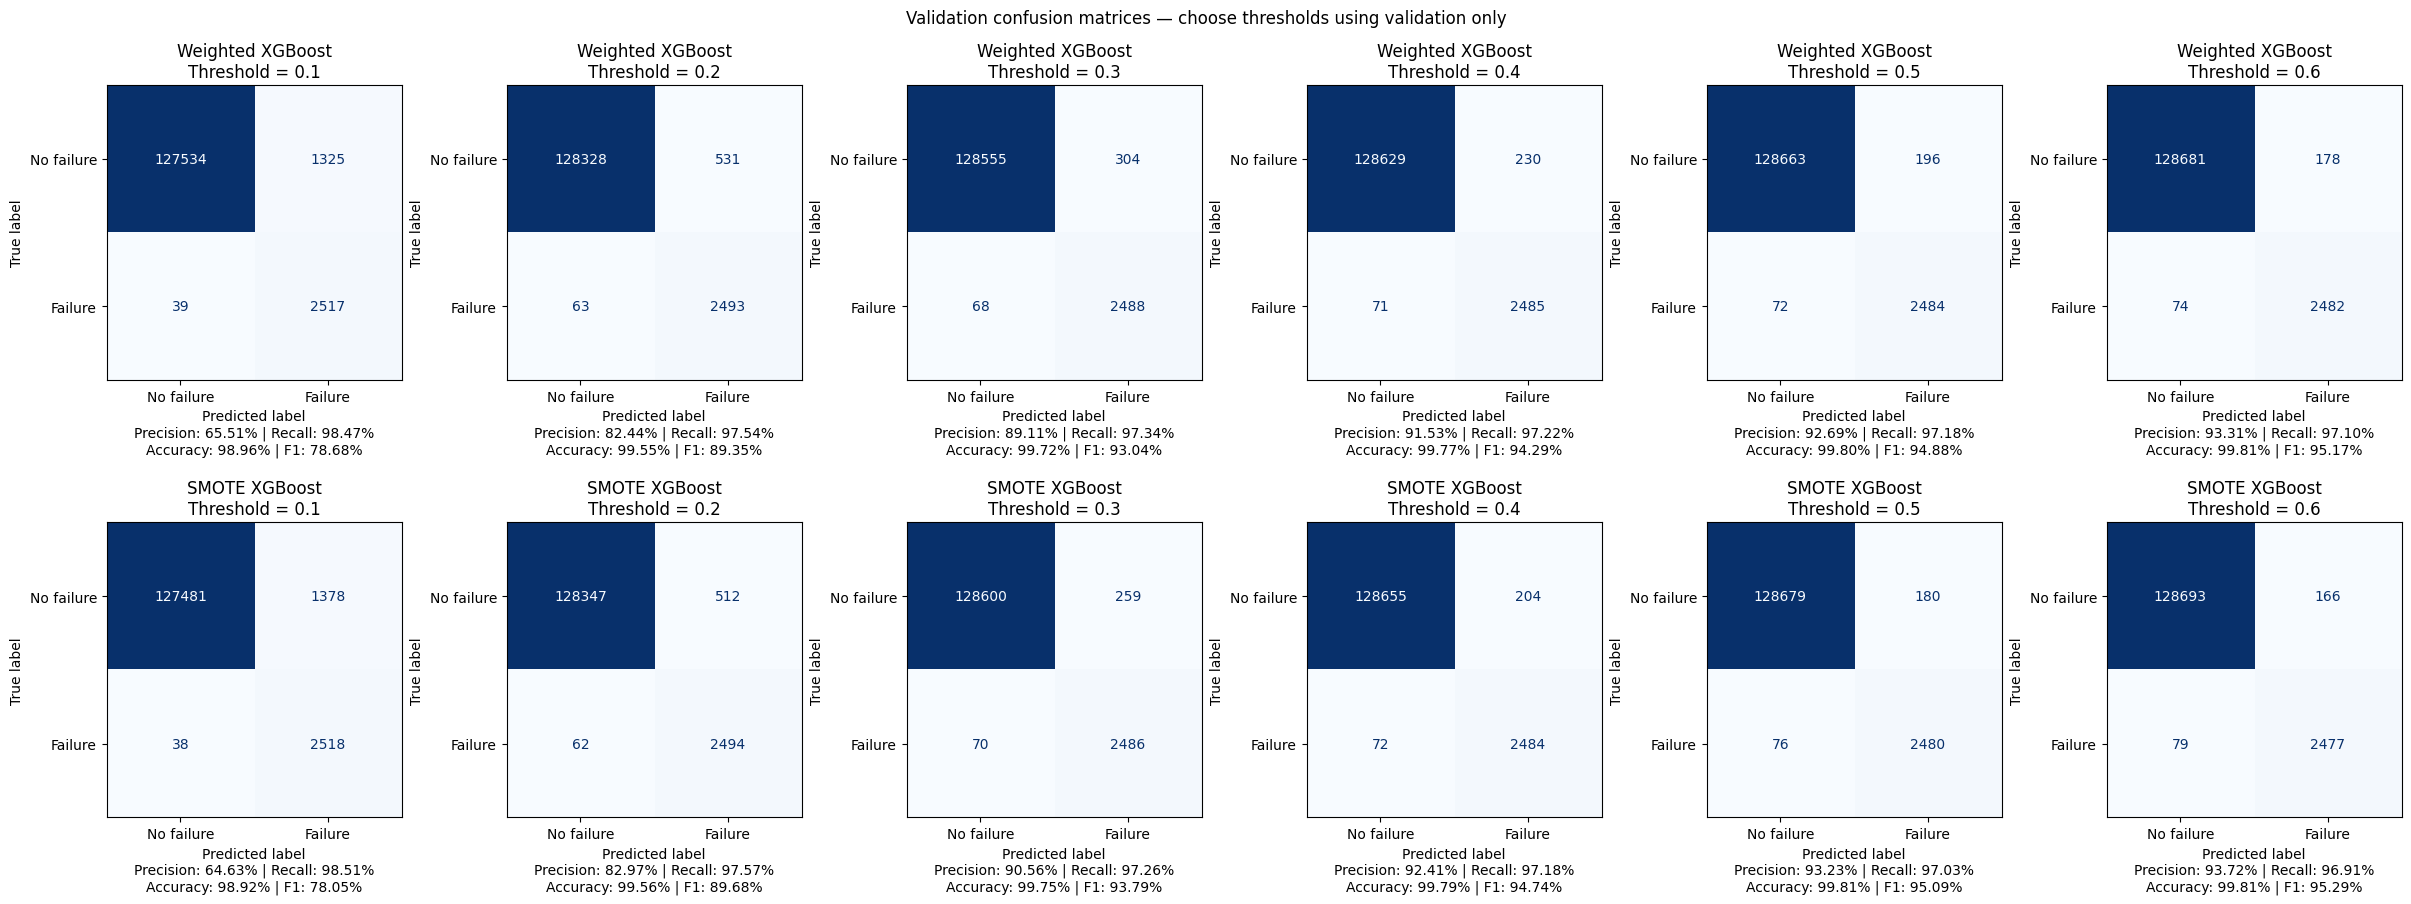

In [56]:
# Compare validation confusion matrices; rows = actual, columns = predicted.
# Optional details remain in validation_comparison and smote_class_distribution.
validation_comparison = pd.concat(
    {"Weighted XGBoost": weighted_validation_metrics, "SMOTE XGBoost": smote_validation_metrics},
    names=["experiment", "threshold"],
)
fig, axes = plt.subplots(2, len(thresholds), figsize=(24, 9), constrained_layout=True)
for row, (name, matrices) in enumerate(
    [
        ("Weighted XGBoost", weighted_validation_confusion_matrices),
        ("SMOTE XGBoost", smote_validation_confusion_matrices),
    ]
):
    for column, threshold in enumerate(thresholds):
        ConfusionMatrixDisplay(
            confusion_matrix=matrices[threshold],
            display_labels=["No failure", "Failure"],
        ).plot(ax=axes[row, column], colorbar=False, cmap="Blues", values_format="d")
        scores = validation_comparison.loc[(name, threshold)]
        axes[row, column].set_title(f"{name}\nThreshold = {threshold:.1f}")
        # Show failure-class precision/recall/F1 and overall accuracy below each matrix.
        axes[row, column].set_xlabel(
            "Predicted label\n"
            f"Precision: {scores['precision']:.2%} | Recall: {scores['recall']:.2%}\n"
            f"Accuracy: {scores['accuracy']:.2%} | F1: {scores['f1']:.2%}",
            fontsize=10,
        )
fig.suptitle("Validation confusion matrices — choose thresholds using validation only")
plt.show()


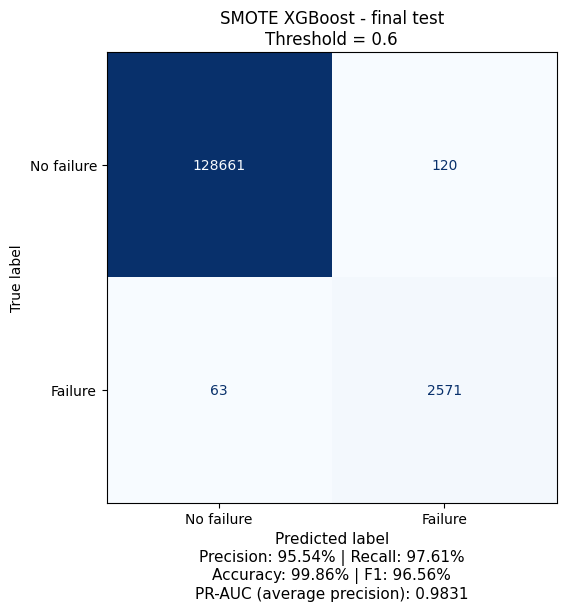

In [57]:
# Finalize SMOTE XGBoost at the user-selected 0.6 threshold; evaluate test once.
selected_smote_threshold = 0.6
X_test_imputed = pd.DataFrame(
    feature_imputer.transform(X_test),
    columns=feature_columns,
    index=X_test.index,
).astype("float32")
smote_test_probabilities = smote_xgb.predict_proba(X_test_imputed)[:, 1]
smote_test_metrics, smote_test_confusion_matrices = threshold_results(
    y_test,
    smote_test_probabilities,
    [selected_smote_threshold],
)
final_test_metrics = pd.concat(
    {"SMOTE XGBoost": smote_test_metrics},
    names=["experiment", "threshold"],
)
final_test_confusion_matrices = {
    "SMOTE XGBoost": smote_test_confusion_matrices[selected_smote_threshold],
}

# Display the finalized model's confusion matrix and scores together.
scores = smote_test_metrics.loc[selected_smote_threshold]
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ConfusionMatrixDisplay(
    confusion_matrix=final_test_confusion_matrices["SMOTE XGBoost"],
    display_labels=["No failure", "Failure"],
).plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title(f"SMOTE XGBoost - final test\nThreshold = {selected_smote_threshold:g}")
ax.set_xlabel(
    "Predicted label\n"
    f"Precision: {scores['precision']:.2%} | Recall: {scores['recall']:.2%}\n"
    f"Accuracy: {scores['accuracy']:.2%} | F1: {scores['f1']:.2%}\n"
    f"PR-AUC (average precision): {scores['pr_auc']:.4f}",
    fontsize=11,
)
plt.show()


## Predict failure for one machine

Reconstruct the same 23 features from the selected machine's earlier history and
four supplied sensor readings, then reuse the fitted imputer and failure model.


In [58]:
# Build one machine's hourly context and reuse the existing trained model.
def _machine_history_at(frame, machine_id, prediction_time, *, include_current=False):
    """Filter by machine first; interpret the dataset's naive timestamps as UTC."""
    selected = frame.loc[frame["machineID"] == machine_id].copy()
    selected["datetime"] = pd.to_datetime(selected["datetime"], utc=True, errors="raise")
    if selected["datetime"].isna().any():
        raise ValueError("Selected machine history contains missing timestamps.")
    if include_current:
        cutoff = selected["datetime"] <= prediction_time
    else:
        cutoff = selected["datetime"] < prediction_time
    return selected.loc[cutoff].sort_values("datetime")


def build_machine_features(machine_id, volt, rotate, pressure, vibration):
    """Public five-input builder; derive the selected machine's next hour internally."""
    machine_times = pd.to_datetime(
        telemetry.loc[telemetry["machineID"] == machine_id, "datetime"],
        utc=True,
        errors="raise",
    )
    if machine_times.empty or machine_times.isna().any():
        raise ValueError("Selected machine needs telemetry with valid timestamps.")
    timestamp = machine_times.max() + pd.Timedelta(hours=1)
    return _build_machine_features_at(
        machine_id,
        volt,
        rotate,
        pressure,
        vibration,
        prediction_time=timestamp,
    )


def _build_machine_features_at(machine_id, volt, rotate, pressure, vibration, *, prediction_time):
    """Internal historical/parity helper; history is strictly before the supplied hour.

    Training's 24-row window includes the current reading and up to 23 past hours.
    Initial standard deviation and unavailable 6-hour change match training's zero fill.
    """
    metadata = machines.loc[machines["machineID"] == machine_id]
    if len(metadata) != 1:
        raise ValueError(f"Expected one known machine record for machineID={machine_id!r}.")

    timestamp = pd.to_datetime(prediction_time, utc=True, errors="raise")
    if pd.isna(timestamp) or timestamp != timestamp.floor("h"):
        raise ValueError("Prediction timestamp must be a valid exact hour to match training.")

    sensors = ["volt", "rotate", "pressure", "vibration"]
    current = pd.Series([volt, rotate, pressure, vibration], index=sensors, dtype="float64")
    if not np.isfinite(current.to_numpy()).all():
        raise ValueError("All four current sensor values must be finite numbers.")

    # Protect rolling statistics and the model's float32 conversion from overflow.
    # This internal numerical safeguard is not a user-facing operating limit.
    numeric_limit = float(np.finfo(np.float32).max / 100)
    numerically_saturated = current.index[current.abs() > numeric_limit].tolist()
    current = current.clip(-numeric_limit, numeric_limit)

    age = float(metadata.iloc[0]["age"])
    if not np.isfinite(age):
        raise ValueError("Selected machine age is missing or invalid.")

    # Use only this machine's strictly earlier telemetry, including for historical tests.
    history = _machine_history_at(telemetry, machine_id, timestamp).tail(23)
    expected_hours = pd.date_range(
        end=timestamp - pd.Timedelta(hours=1), periods=len(history), freq="h"
    )
    if not pd.DatetimeIndex(history["datetime"]).equals(expected_hours):
        raise ValueError(
            "Selected machine needs consecutive hourly telemetry ending one hour before prediction; "
            "history is duplicated or has gaps."
        )
    past_values = history[sensors].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(past_values.to_numpy()).all():
        raise ValueError("Selected machine sensor history contains missing or non-finite readings.")
    window_values = pd.concat([past_values, current.to_frame().T], ignore_index=True)
    features = current.to_dict()
    features["age"] = age
    for sensor in sensors:
        mean = window_values[sensor].mean()
        features[f"{sensor}_24h_mean"] = mean
        if len(window_values) > 1:
            features[f"{sensor}_24h_std"] = window_values[sensor].std(ddof=1)
        else:
            features[f"{sensor}_24h_std"] = 0.0
        features[f"{sensor}_vs_24h_mean"] = current[sensor] - mean
        # Match the training cell's shift(6).fillna(0) for short initial histories.
        if len(history) >= 6:
            features[f"{sensor}_6h_change"] = current[sensor] - past_values[sensor].iloc[-6]
        else:
            features[f"{sensor}_6h_change"] = 0.0

    # Match the original event boundaries: errors in (t-24h, t], maintenance <= t.
    machine_errors = _machine_history_at(errors, machine_id, timestamp, include_current=True)
    recent_errors = machine_errors.loc[
        machine_errors["datetime"] > timestamp - pd.Timedelta(hours=24)
    ]
    machine_maintenance = _machine_history_at(maint, machine_id, timestamp, include_current=True)
    features["errors_last_24h"] = len(recent_errors)
    if machine_maintenance.empty:
        features["hours_since_last_maintenance"] = np.nan
    else:
        last_maintenance = machine_maintenance["datetime"].iloc[-1]
        features["hours_since_last_maintenance"] = (
            timestamp - last_maintenance
        ).total_seconds() / 3600

    # Check machine and time isolation once, where history becomes model features.
    for machine_history in [history, recent_errors, machine_maintenance]:
        assert machine_history["machineID"].eq(machine_id).all(), "Mixed machine history."
    assert (history["datetime"] < timestamp).all(), "Future telemetry in model inputs."
    assert (recent_errors["datetime"] <= timestamp).all() and (
        machine_maintenance["datetime"] <= timestamp
    ).all()

    # Preserve the fitted model/imputer schema; raw machine ID is never a feature.
    model_columns = smote_xgb.feature_names_in_.tolist()
    if model_columns != list(feature_columns) or model_columns != list(
        feature_imputer.feature_names_in_
    ):
        raise ValueError("Model, imputer and feature_columns have different feature names/order.")
    if set(features) != set(model_columns):
        raise ValueError(
            "The contextual feature builder does not match the trained feature schema."
        )
    feature_row = pd.DataFrame([features], columns=model_columns)
    feature_row.attrs["context"] = {
        "machine_id": machine_id.item() if isinstance(machine_id, np.generic) else machine_id,
        "prediction_time": timestamp.isoformat(),
        "telemetry_machine_ids": history["machineID"].unique().tolist(),
        "telemetry_rows": len(history),
        "telemetry_start": history["datetime"].iloc[0].isoformat() if len(history) else None,
        "telemetry_end": history["datetime"].iloc[-1].isoformat() if len(history) else None,
        "error_machine_ids": recent_errors["machineID"].unique().tolist(),
        "maintenance_machine_ids": machine_maintenance["machineID"].unique().tolist(),
    }
    feature_row.attrs["numerically_saturated_sensors"] = numerically_saturated
    return feature_row


def predict_machine_failure(machine_id, volt, rotate, pressure, vibration):
    """Use the same class-1 probability for the failure label and percentage."""
    feature_row = build_machine_features(
        machine_id=machine_id,
        volt=volt,
        rotate=rotate,
        pressure=pressure,
        vibration=vibration,
    )
    prepared_input = pd.DataFrame(
        feature_imputer.transform(feature_row),
        columns=feature_columns,
    ).astype("float32")
    failure_class_index = list(smote_xgb.classes_).index(1)
    failure_probability = float(smote_xgb.predict_proba(prepared_input)[0, failure_class_index])
    failure = "Yes" if failure_probability >= selected_smote_threshold else "No"
    failure_risk_percent = failure_probability * 100
    return {
        "failure": failure,
        "failure_probability_percent": failure_risk_percent,
    }


In [59]:
# Five reproducible random examples; these sampling ranges are not input limits.
rng = np.random.default_rng(42)
test_results = []
for case in range(5):
    inputs = {
        "machine_id": int(rng.choice(machines["machineID"].to_numpy())),
        "vibration": round(float(rng.uniform(25, 55) if case < 2 else rng.uniform(0, 250)), 2),
        "rotate": round(float(rng.uniform(350, 550) if case < 2 else rng.uniform(0, 1500)), 2),
        "volt": round(float(rng.uniform(140, 200) if case < 2 else rng.uniform(0, 1200)), 2),
        "pressure": round(float(rng.uniform(80, 120) if case < 2 else rng.uniform(0, 400)), 2),
    }
    result = predict_machine_failure(**inputs)
    test_results.append({**inputs, **result})

final_user_output = pd.DataFrame(test_results).rename(
    columns={
        "machine_id": "Machine ID",
        "vibration": "Vibration",
        "rotate": "Rotate",
        "volt": "Volt",
        "pressure": "Pressure",
        "failure": "Failure",
        "failure_probability_percent": "Failure probability (%)",
    }
)


# Format only for display; retain the exact percentage in the returned result.
# Show extra digits if two-decimal rounding would cross the decision threshold.
def _format_failure_percent(value):
    text = f"{value:.2f}"
    if (float(text) >= selected_smote_threshold * 100) != (value >= selected_smote_threshold * 100):
        return repr(float(value))
    return text


print(
    final_user_output.to_string(
        index=False,
        formatters={"Failure probability (%)": _format_failure_percent},
    )
)

# Additional verified positive prediction using the existing trained model.
positive_case_inputs = {
    "machine_id": 58,
    "vibration": 2.25,
    "rotate": 268.74,
    "volt": 218.06,
    "pressure": 230.66,
}
positive_case_result = predict_machine_failure(**positive_case_inputs)
print("\nVerified positive case:")
print(positive_case_inputs)
print(f"Failure: {positive_case_result['failure']}")
print(f"Failure probability: {positive_case_result['failure_probability_percent']:.2f}%")


 Machine ID  Vibration  Rotate   Volt  Pressure Failure Failure probability (%)
          9      38.17  521.72 181.84     83.77      No                    0.01
         78      54.27  502.23 187.16     85.12      No                    0.93
         84      92.70 1390.15 772.64    329.10      No                    2.11
         46     110.85  340.86 665.50     25.53      No                    1.42
         86     157.92 1137.13 425.43    388.28      No                    1.52

Verified positive case:
{'machine_id': 58, 'vibration': 2.25, 'rotate': 268.74, 'volt': 218.06, 'pressure': 230.66}
Failure: Yes
Failure probability: 60.23%


In [60]:
predict_machine_failure(machine_id=58, vibration=2.25, rotate=268.74, volt=218.06, pressure=230.66)


{'failure': 'Yes', 'failure_probability_percent': 60.228753089904785}

### Review the existing validation thresholds

This review reports the original comparison while keeping the selected threshold at 0.60.


In [61]:
# Review the existing validation predictions; keep the selected threshold unchanged.
threshold_review_records = []
for review_threshold in np.arange(50, 76) / 100:
    review_predictions = (smote_validation_probabilities >= review_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_validation, review_predictions, labels=[0, 1]).ravel()
    threshold_review_records.append(
        {
            "threshold": float(review_threshold),
            "precision": precision_score(y_validation, review_predictions, zero_division=0),
            "recall": recall_score(y_validation, review_predictions, zero_division=0),
            "f1": f1_score(y_validation, review_predictions, zero_division=0),
            "accuracy": accuracy_score(y_validation, review_predictions),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        }
    )
smote_validation_threshold_review = (
    pd.DataFrame(threshold_review_records).set_index("threshold").sort_index()
)
review_pr_auc = average_precision_score(y_validation, smote_validation_probabilities)
review_best_threshold = float(smote_validation_threshold_review["f1"].idxmax())
print(smote_validation_threshold_review.to_string(float_format="{:.4f}".format))
print(f"Validation PR-AUC (average precision, all thresholds): {review_pr_auc:.6f}")
for review_label, review_threshold in [
    ("Current", selected_smote_threshold),
    ("Best validation F1", review_best_threshold),
]:
    review_threshold_metrics = smote_validation_threshold_review.loc[review_threshold]
    print(
        f"{review_label}: threshold={review_threshold:.2f}, Precision={review_threshold_metrics['precision']:.4%}, Recall={review_threshold_metrics['recall']:.4%}, F1={review_threshold_metrics['f1']:.4%}; TN={int(review_threshold_metrics['TN'])}, FP={int(review_threshold_metrics['FP'])}, FN={int(review_threshold_metrics['FN'])}, TP={int(review_threshold_metrics['TP'])}"
    )
if review_best_threshold != selected_smote_threshold:
    print(
        f"Recommendation only: consider {review_best_threshold:.2f} for highest validation F1 in this grid, subject to the precision/recall tradeoff. Current threshold remains 0.60."
    )
else:
    print("Recommendation: retain 0.60; it has the highest validation F1 in this grid.")
print("Test data was NOT used for this threshold comparison or recommendation.")


           precision  recall     f1  accuracy      TN   FP  FN    TP
threshold                                                           
0.50          0.9323  0.9703 0.9509    0.9981  128679  180  76  2480
0.51          0.9330  0.9699 0.9511    0.9981  128681  178  77  2479
0.52          0.9344  0.9699 0.9518    0.9981  128685  174  77  2479
0.53          0.9351  0.9695 0.9520    0.9981  128687  172  78  2478
0.54          0.9351  0.9695 0.9520    0.9981  128687  172  78  2478
0.55          0.9351  0.9691 0.9518    0.9981  128687  172  79  2477
0.56          0.9351  0.9691 0.9518    0.9981  128687  172  79  2477
0.57          0.9354  0.9691 0.9520    0.9981  128688  171  79  2477
0.58          0.9354  0.9691 0.9520    0.9981  128688  171  79  2477
0.59          0.9361  0.9691 0.9523    0.9981  128690  169  79  2477
0.60          0.9372  0.9691 0.9529    0.9981  128693  166  79  2477
0.61          0.9379  0.9691 0.9532    0.9982  128695  164  79  2477
0.62          0.9379  0.9691 0.953

## Separate unsupervised sensor anomaly baseline

This phase asks **“Is the machine's current sensor behaviour unusual compared with
learned operating behaviour?”** The finalized failure phase asks whether it will fail
in the next 24 hours; its cells, model, 23 features, imputer and 0.60 threshold stay frozen.

Isolation Forest learns only the original training machines' 16 sensor-behaviour
features. There are no true anomaly labels, so the checks below describe distributions
and relationships, not anomaly accuracy, precision, recall, F1 or AUC.
The inherited machine split is retained (including its original failure-count
stratification); failure labels are not inputs to anomaly fitting or tuning.

`anomaly_score = -decision_function(X)`: larger means more abnormal. A score **> 0**
is `Anomaly Detected`; a score **<= 0** is `Normal`, using Isolation Forest's automatic
boundary without tuning. This relative model score is **not a probability, failure
probability or percentage**. Raw predictions (`1` normal, `-1` anomaly) stay internal.

In [62]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

anomaly_feature_columns = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "volt_24h_std",
    "rotate_24h_std",
    "pressure_24h_std",
    "vibration_24h_std",
    "volt_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "vibration_vs_24h_mean",
    "volt_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "vibration_6h_change",
]

_anomaly_source_frames = {"train": train_df, "validation": validation_df, "test": test_df}
print("Frozen anomaly features (16):", anomaly_feature_columns)


Frozen anomaly features (16): ['volt', 'rotate', 'pressure', 'vibration', 'volt_24h_std', 'rotate_24h_std', 'pressure_24h_std', 'vibration_24h_std', 'volt_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean', 'vibration_vs_24h_mean', 'volt_6h_change', 'rotate_6h_change', 'pressure_6h_change', 'vibration_6h_change']


In [63]:
# Select only the anomaly sensor features from the original machine splits.
X_anomaly_train_raw = (
    train_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
)
X_anomaly_validation_raw = (
    validation_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
)
X_anomaly_test_raw = (
    test_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
)

# Learn medians from original training rows only; there is no target or SMOTE here.
anomaly_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
anomaly_imputer.fit(X_anomaly_train_raw)

X_anomaly_train = pd.DataFrame(
    anomaly_imputer.transform(X_anomaly_train_raw),
    index=X_anomaly_train_raw.index,
    columns=anomaly_feature_columns,
)
X_anomaly_validation = pd.DataFrame(
    anomaly_imputer.transform(X_anomaly_validation_raw),
    index=X_anomaly_validation_raw.index,
    columns=anomaly_feature_columns,
)
X_anomaly_test = pd.DataFrame(
    anomaly_imputer.transform(X_anomaly_test_raw),
    index=X_anomaly_test_raw.index,
    columns=anomaly_feature_columns,
)
_anomaly_prepared_frames = {
    "train": X_anomaly_train,
    "validation": X_anomaly_validation,
    "test": X_anomaly_test,
}
print("Separate median imputer fitted on original training rows only; no SMOTE or scaling.")


Separate median imputer fitted on original training rows only; no SMOTE or scaling.


In [64]:
# Fit only the original training rows using the existing configuration.
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)
isolation_forest.fit(X_anomaly_train)
print(isolation_forest)
print(f"Fitted on {len(X_anomaly_train):,} real rows from {len(train_ids)} training machines.")


IsolationForest(n_estimators=300, n_jobs=-1, random_state=42)
Fitted on 613,270 real rows from 70 training machines.


In [65]:
# Keep outputs in separate tables. Never attach them to df or the supervised splits.
anomaly_results = {}
_anomaly_summary_rows = []
for _anomaly_name, _anomaly_X in _anomaly_prepared_frames.items():
    _anomaly_result = (
        _anomaly_source_frames[_anomaly_name]
        .loc[:, ["machineID", "datetime"] + anomaly_feature_columns]
        .copy()
    )
    _anomaly_prediction = isolation_forest.predict(_anomaly_X)
    _anomaly_decision = isolation_forest.decision_function(_anomaly_X)
    _anomaly_result["isolation_prediction"] = _anomaly_prediction  # Internal only.
    _anomaly_result["decision_score"] = _anomaly_decision
    _anomaly_result["anomaly_score"] = (
        -_anomaly_decision
    )  # Larger = more abnormal, NOT probability.
    _anomaly_result["anomaly_status"] = np.where(
        _anomaly_prediction == -1, "Anomaly Detected", "Normal"
    )
    anomaly_results[_anomaly_name] = _anomaly_result
    _anomaly_count = int((_anomaly_prediction == -1).sum())
    _anomaly_summary_rows.append(
        {
            "split": _anomaly_name,
            "rows": len(_anomaly_X),
            "anomaly_rows": _anomaly_count,
            "normal_rows": len(_anomaly_X) - _anomaly_count,
            "anomaly_pct": 100 * _anomaly_count / len(_anomaly_X),
            "score_min": float(_anomaly_result["anomaly_score"].min()),
            "score_median": float(_anomaly_result["anomaly_score"].median()),
            "score_max": float(_anomaly_result["anomaly_score"].max()),
        }
    )
    print(f"Scored {_anomaly_name}: {len(_anomaly_X):,} rows.", flush=True)
anomaly_summary = pd.DataFrame(_anomaly_summary_rows).set_index("split")
print("Unsupervised distribution only; no true anomaly labels or anomaly classification metrics.")
print(
    anomaly_summary.rename(
        columns={
            "rows": "Rows",
            "anomaly_rows": "Anomaly rows",
            "normal_rows": "Normal rows",
            "anomaly_pct": "Anomaly (%)",
            "score_min": "Score min",
            "score_median": "Score median",
            "score_max": "Score max",
        }
    ).to_string(float_format="{:.4f}".format)
)


Scored train: 613,270 rows.
Scored validation: 131,415 rows.
Scored test: 131,415 rows.
Unsupervised distribution only; no true anomaly labels or anomaly classification metrics.
              Rows  Anomaly rows  Normal rows  Anomaly (%)  Score min  Score median  Score max
split                                                                                         
train       613270         36856       576414       6.0098    -0.1364       -0.0689     0.1677
validation  131415          8059       123356       6.1325    -0.1360       -0.0687     0.1490
test        131415          7901       123514       6.0123    -0.1357       -0.0690     0.1503


In [66]:
anomaly_by_machine = {}
_anomaly_machine_summary_rows = []
for _anomaly_name, _anomaly_result in anomaly_results.items():
    _anomaly_counts = (
        _anomaly_result.assign(_flag=_anomaly_result["anomaly_status"].eq("Anomaly Detected"))
        .groupby("machineID")["_flag"]
        .agg(rows="size", anomaly_rows="sum")
    )
    _anomaly_counts["anomaly_pct"] = 100 * _anomaly_counts["anomaly_rows"] / _anomaly_counts["rows"]
    _anomaly_total = int(_anomaly_counts["anomaly_rows"].sum())
    _anomaly_counts["share_of_anomalies_pct"] = (
        100 * _anomaly_counts["anomaly_rows"] / _anomaly_total if _anomaly_total else 0.0
    )
    anomaly_by_machine[_anomaly_name] = _anomaly_counts
    _anomaly_active = int(_anomaly_counts["anomaly_rows"].gt(0).sum())
    _anomaly_share = float(_anomaly_counts["share_of_anomalies_pct"].max())
    _anomaly_machine_summary_rows.append(
        {
            "split": _anomaly_name,
            "machines": len(_anomaly_counts),
            "min_anomaly_pct": _anomaly_counts["anomaly_pct"].min(),
            "median_anomaly_pct": _anomaly_counts["anomaly_pct"].median(),
            "max_anomaly_pct": _anomaly_counts["anomaly_pct"].max(),
            "machines_with_anomalies": _anomaly_active,
            "largest_anomaly_share_pct": _anomaly_share,
            "largest_share_machine": (
                int(_anomaly_counts["anomaly_rows"].idxmax()) if _anomaly_total else None
            ),
            "one_machine_dominates": _anomaly_share > 50.0,
            "all_anomalies_in_one_machine": _anomaly_active == 1,
        }
    )
    if _anomaly_name in ("validation", "test"):
        print(f"\n{_anomaly_name.title()} anomalies by machine:")
        print(
            _anomaly_counts.rename_axis("Machine ID")
            .rename(
                columns={
                    "rows": "Rows",
                    "anomaly_rows": "Anomaly rows",
                    "anomaly_pct": "Anomaly (%)",
                    "share_of_anomalies_pct": "Share of split anomalies (%)",
                }
            )
            .to_string(float_format="{:.3f}".format)
        )
anomaly_machine_summary = pd.DataFrame(_anomaly_machine_summary_rows).set_index("split")
print("\nMachine concentration: 'dominates' means more than 50% of a split's anomalies.")
print(anomaly_machine_summary.to_string(float_format="{:.3f}".format))
if anomaly_machine_summary["all_anomalies_in_one_machine"].any():
    print("REVIEW: a split's anomalies are entirely concentrated in one machine.")

_anomaly_display_labels = {
    "machineID": "Machine ID",
    "datetime": "Reading time",
    "volt": "Voltage",
    "rotate": "Rotation Speed",
    "pressure": "Pressure",
    "vibration": "Vibration",
    "anomaly_score": "Anomaly score (relative)",
    "anomaly_status": "Anomaly status",
}
for _anomaly_sensor, _anomaly_label in [
    ("volt", "Voltage"),
    ("rotate", "Rotation Speed"),
    ("pressure", "Pressure"),
    ("vibration", "Vibration"),
]:
    _anomaly_display_labels.update(
        {
            f"{_anomaly_sensor}_24h_std": f"{_anomaly_label}: 24h standard deviation",
            f"{_anomaly_sensor}_vs_24h_mean": f"{_anomaly_label}: deviation from 24h mean",
            f"{_anomaly_sensor}_6h_change": f"{_anomaly_label}: 6h change",
        }
    )
anomaly_top10_test = (
    anomaly_results["test"]
    .nlargest(10, "anomaly_score")
    .loc[
        :, ["machineID", "datetime"] + anomaly_feature_columns + ["anomaly_score", "anomaly_status"]
    ]
    .rename(columns=_anomaly_display_labels)
)
print("\nTop 10 most anomalous test readings (descriptive review only):")
display(anomaly_top10_test.style.format(precision=3))



Validation anomalies by machine:
            Rows  Anomaly rows  Anomaly (%)  Share of split anomalies (%)
Machine ID                                                               
11          8761           530        6.050                         6.576
22          8761           566        6.460                         7.023
35          8761           539        6.152                         6.688
38          8761           543        6.198                         6.738
41          8761           538        6.141                         6.676
49          8761           623        7.111                         7.730
50          8761           467        5.330                         5.795
52          8761           565        6.449                         7.011
59          8761           449        5.125                         5.571
60          8761           548        6.255                         6.800
66          8761           566        6.460                         7.023
71  

,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
307641,36,2015-02-12 04:00:00,191.716,584.845,76.227,61.400,13.658,62.870,11.475,8.924,19.789,110.505,-24.356,18.652,10.965,53.883,-44.712,23.999,0.150,Anomaly Detected
293387,34,2015-06-28 08:00:00,134.577,565.662,88.865,32.631,17.883,59.188,14.802,5.581,-56.252,117.719,-33.664,-7.313,-66.105,256.749,-43.784,-12.962,0.148,Anomaly Detected
564744,65,2015-06-18 14:00:00,135.334,532.442,76.275,32.637,15.510,82.020,10.316,7.088,-29.730,120.377,-21.144,-15.411,-32.153,1.575,-28.388,-12.752,0.130,Anomaly Detected
131389,15,2015-12-31 05:00:00,210.361,538.382,136.618,54.532,17.373,65.202,13.075,7.456,39.205,85.189,35.514,-3.275,44.761,64.215,54.930,10.337,0.128,Anomaly Detected
475852,55,2015-04-26 04:00:00,199.685,535.811,125.225,56.559,14.460,52.777,15.614,6.257,32.837,81.877,18.693,16.038,42.588,89.291,34.801,19.329,0.127,Anomaly Detected
565362,65,2015-07-14 08:00:00,191.372,570.690,77.855,32.579,18.368,69.433,11.493,6.062,20.840,116.606,-23.528,-9.162,15.394,106.637,-41.741,-17.382,0.126,Anomaly Detected
414852,48,2015-05-09 19:00:00,140.473,260.262,82.327,55.671,16.536,78.124,11.391,5.134,-29.595,-142.486,-19.130,11.430,-25.571,-170.534,-17.652,13.352,0.121,Anomaly Detected
193209,23,2015-01-20 17:00:00,134.954,307.689,107.078,30.514,15.612,54.692,8.783,8.738,-32.113,-139.096,6.346,-15.815,-38.161,-168.213,11.227,-23.077,0.120,Anomaly Detected
416286,48,2015-07-08 13:00:00,132.074,268.072,114.184,35.641,14.349,72.937,8.897,6.448,-39.782,-167.822,16.688,-2.561,-49.255,-196.912,19.160,4.575,0.113,Anomaly Detected
866872,99,2015-12-12 20:00:00,146.769,313.199,140.770,41.569,13.195,73.467,13.080,6.996,-19.613,-100.782,33.378,-3.048,-26.089,-52.685,42.341,-7.396,0.110,Anomaly Detected


### Failure/error relationship — analysis only

Predictions and the automatic boundary are already fixed. The following table joins
existing failure/error information by the preserved row index only for descriptive
comparison. `failure_next_24h` is a failure label, **not anomaly ground truth**.
**Failure labels were not used to train or tune the anomaly detector.**
No contamination or anomaly boundary is selected from these results.

In [67]:
_anomaly_relationship_rows = []
for _anomaly_name, _anomaly_result in anomaly_results.items():
    _anomaly_source = _anomaly_source_frames[_anomaly_name]
    _anomaly_analysis = _anomaly_result[["anomaly_status"]].join(
        _anomaly_source[["failure_next_24h", "errors_last_24h"]],
        validate="one_to_one",
    )
    for _anomaly_status, _anomaly_group in _anomaly_analysis.groupby("anomaly_status"):
        _anomaly_relationship_rows.append(
            {
                "split": _anomaly_name,
                "status": _anomaly_status,
                "rows": len(_anomaly_group),
                "failure_next_24h_pct": 100 * _anomaly_group["failure_next_24h"].mean(),
                "mean_recent_errors": _anomaly_group["errors_last_24h"].mean(),
                "median_recent_errors": _anomaly_group["errors_last_24h"].median(),
            }
        )
anomaly_failure_relationship = pd.DataFrame(_anomaly_relationship_rows).set_index(
    ["split", "status"]
)
print("Failure labels were not used to train or tune the anomaly detector.")
print(
    anomaly_failure_relationship.rename(
        columns={
            "rows": "Rows",
            "failure_next_24h_pct": "Failure within 24h (%)",
            "mean_recent_errors": "Recent errors: mean",
            "median_recent_errors": "Recent errors: median",
        }
    ).to_string(float_format="{:.4f}".format)
)


Failure labels were not used to train or tune the anomaly detector.
                               Rows  Failure within 24h (%)  Recent errors: mean  Recent errors: median
split      status                                                                                      
train      Anomaly Detected   36856                  2.9385               0.1221                 0.0000
           Normal            576414                  1.8929               0.1046                 0.0000
validation Anomaly Detected    8059                  3.5861               0.1475                 0.0000
           Normal            123356                  1.8378               0.1168                 0.0000
test       Anomaly Detected    7901                  3.0249               0.1116                 0.0000
           Normal            123514                  1.9391               0.1029                 0.0000


### Five-input anomaly inference

The same selected-machine context and next-hour convention as failure inference are
used: the existing builder obtains up to 23 strictly earlier hourly readings and adds
the supplied current sensors. It retains its existing metadata/history requirements;
only the 16 sensor features enter this independent imputer and model.

Typical-looking and deliberately unusual examples below are reproducible interface
and safety demonstrations. They do not establish anomaly detection quality, and a
typical-looking reading can still be unusual relative to its machine's recent history.

In [68]:
def predict_machine_anomaly(machine_id, volt, rotate, pressure, vibration):
    """Score the selected machine's next-hour sensor context.

    A positive anomaly_score means Anomaly Detected. The score is relative,
    not a probability; larger values mean more unusual sensor behaviour.
    """
    feature_row = build_machine_features(machine_id, volt, rotate, pressure, vibration)
    raw = feature_row.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
    prepared = pd.DataFrame(
        anomaly_imputer.transform(raw),
        index=raw.index,
        columns=anomaly_feature_columns,
    )
    prediction = int(isolation_forest.predict(prepared)[0])
    score = float(-isolation_forest.decision_function(prepared)[0])
    return {
        "anomaly_detected": "Yes" if prediction == -1 else "No",
        "anomaly_status": "Anomaly Detected" if prediction == -1 else "Normal",
        "anomaly_score": score,
    }


In [69]:
# Deterministic choices from training machines; no selection based on predictions or failure labels.
_anomaly_example_ids = sorted(train_ids)[:2]
anomaly_inference_examples = []
for _anomaly_id in _anomaly_example_ids:
    _anomaly_recent = (
        telemetry.loc[telemetry["machineID"] == _anomaly_id].sort_values("datetime").tail(23)
    )
    _anomaly_typical = _anomaly_recent[["volt", "rotate", "pressure", "vibration"]].median()
    for _anomaly_case, _anomaly_values in [
        ("Typical recent sensors", _anomaly_typical.to_dict()),
        (
            "Unusual synthetic sensors",
            dict(volt=1000.0, rotate=50.0, pressure=400.0, vibration=200.0),
        ),
    ]:
        _anomaly_inputs = {"machine_id": int(_anomaly_id)}
        for sensor, value in _anomaly_values.items():
            _anomaly_inputs[sensor] = float(value)
        anomaly_inference_examples.append(
            {
                "example": _anomaly_case,
                **_anomaly_inputs,
                **predict_machine_anomaly(**_anomaly_inputs),
            }
        )
anomaly_inference_examples = pd.DataFrame(anomaly_inference_examples)
print(
    anomaly_inference_examples.rename(
        columns={
            **_anomaly_display_labels,
            "machine_id": "Machine ID",
            "example": "Example",
            "anomaly_detected": "Anomaly detected",
        }
    ).to_string(index=False, float_format="{:.5f}".format)
)
print("These examples test inference and safety; synthetic extremes do not prove model quality.")


                  Example  Machine ID    Voltage  Rotation Speed  Pressure  Vibration Anomaly detected   Anomaly status  Anomaly score (relative)
   Typical recent sensors           1  171.97893       448.99852  95.56826   42.11166               No           Normal                  -0.12431
Unusual synthetic sensors           1 1000.00000        50.00000 400.00000  200.00000              Yes Anomaly Detected                   0.24908
   Typical recent sensors           2  170.13564       442.24455  99.94629   40.54597               No           Normal                  -0.09542
Unusual synthetic sensors           2 1000.00000        50.00000 400.00000  200.00000              Yes Anomaly Detected                   0.24908
These examples test inference and safety; synthetic extremes do not prove model quality.


## Review of the fitted anomaly baseline (no training or configuration changes)

Reuse the existing real-row predictions in `anomaly_results`. Larger
`anomaly_score = -decision_function(X)` values mean more anomalous; scores above zero
are flagged. Scores are relative model scores, **not probabilities or percentages**.
There are no anomaly ground-truth labels. Failure labels and error counts enter only
the post-hoc relationship table; they are not used to select the anomaly boundary.
This review reuses the fitted models and their saved predictions.

In [70]:
_review_sources = _anomaly_source_frames
review_isolation_parameters = isolation_forest.get_params(deep=False)
print("Current fitted Isolation Forest parameters:", review_isolation_parameters)
print(
    "Actual samples per tree:",
    isolation_forest.max_samples_,
    "; automatic offset:",
    isolation_forest.offset_,
)
print("Feature schema:", anomaly_feature_columns)

_review_distribution_records = []
for _review_split, _review_frame in anomaly_results.items():
    _review_scores = _review_frame["anomaly_score"]
    _review_flags = _review_frame["anomaly_status"].eq("Anomaly Detected")
    _review_distribution_records.append(
        {
            "Split": _review_split,
            "Rows": len(_review_frame),
            "Normal rows": int((~_review_flags).sum()),
            "Anomalous rows": int(_review_flags.sum()),
            "Anomaly (%)": 100 * _review_flags.mean(),
            "Score minimum": _review_scores.min(),
            "Score median": _review_scores.median(),
            "Score mean": _review_scores.mean(),
            "Score maximum": _review_scores.max(),
        }
    )
review_anomaly_distribution = pd.DataFrame(_review_distribution_records).set_index("Split")
print("\nLarger scores mean more anomalous. The score is not a probability.")
print(review_anomaly_distribution.to_string(float_format="{:.6f}".format))


Current fitted Isolation Forest parameters: {'bootstrap': False, 'contamination': 'auto', 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Actual samples per tree: 256 ; automatic offset: -0.5
Feature schema: ['volt', 'rotate', 'pressure', 'vibration', 'volt_24h_std', 'rotate_24h_std', 'pressure_24h_std', 'vibration_24h_std', 'volt_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean', 'vibration_vs_24h_mean', 'volt_6h_change', 'rotate_6h_change', 'pressure_6h_change', 'vibration_6h_change']

Larger scores mean more anomalous. The score is not a probability.
              Rows  Normal rows  Anomalous rows  Anomaly (%)  Score minimum  Score median  Score mean  Score maximum
Split                                                                                                               
train       613270       576414           36856     6.009751      -0.136383     -0.068942   -0.063206       0.1

In [71]:
# Rates for every held-out machine, plus exposure-adjusted concentration checks.
review_machine_rates = {}
_review_machine_records = []
for _review_split in ("validation", "test"):
    _review_frame = anomaly_results[_review_split]
    _review_rates = (
        _review_frame.assign(_review_flag=_review_frame["anomaly_status"].eq("Anomaly Detected"))
        .groupby("machineID")["_review_flag"]
        .agg(**{"Rows": "size", "Anomalous rows": "sum"})
    )
    _review_rates.index.name = "Machine ID"
    _review_rates["Anomaly (%)"] = 100 * _review_rates["Anomalous rows"] / _review_rates["Rows"]
    _review_total = _review_rates["Anomalous rows"].sum()
    _review_rates["Share of anomalies (%)"] = (
        100 * _review_rates["Anomalous rows"] / _review_total if _review_total else 0.0
    )
    _review_rates["Share of rows (%)"] = 100 * _review_rates["Rows"] / _review_rates["Rows"].sum()
    _review_rates["Anomaly share / row share"] = (
        _review_rates["Share of anomalies (%)"] / _review_rates["Share of rows (%)"]
    )
    review_machine_rates[_review_split] = _review_rates
    _review_top1 = _review_rates.nlargest(1, "Anomalous rows")
    _review_top3 = _review_rates.nlargest(3, "Anomalous rows")
    _review_machine_records.append(
        {
            "Split": _review_split,
            "Minimum (%)": _review_rates["Anomaly (%)"].min(),
            "Median (%)": _review_rates["Anomaly (%)"].median(),
            "Mean (%)": _review_rates["Anomaly (%)"].mean(),
            "Maximum (%)": _review_rates["Anomaly (%)"].max(),
            "Machines with anomalies": int(_review_rates["Anomalous rows"].gt(0).sum()),
            "Total machines": len(_review_rates),
            "Top 1 anomaly share (%)": _review_top1["Share of anomalies (%)"].sum(),
            "Top 1 row share (%)": _review_top1["Share of rows (%)"].sum(),
            "Top 3 anomaly share (%)": _review_top3["Share of anomalies (%)"].sum(),
            "Top 3 row share (%)": _review_top3["Share of rows (%)"].sum(),
            "Maximum share / exposure": _review_rates["Anomaly share / row share"].max(),
        }
    )
    print(f"\n{_review_split.title()}: every machine")
    print(_review_rates.to_string(float_format="{:.4f}".format))
    print("\nFive highest anomaly rates:")
    print(_review_rates.nlargest(5, "Anomaly (%)").to_string(float_format="{:.4f}".format))
    print("\nFive lowest anomaly rates:")
    print(_review_rates.nsmallest(5, "Anomaly (%)").to_string(float_format="{:.4f}".format))
review_machine_distribution = pd.DataFrame(_review_machine_records).set_index("Split")
print("\nMachine rate and concentration summary:")
print(review_machine_distribution.to_string(float_format="{:.4f}".format))
print(
    "Compare anomaly shares with row exposure; these are descriptive checks, not a statistical significance test."
)



Validation: every machine
            Rows  Anomalous rows  Anomaly (%)  Share of anomalies (%)  Share of rows (%)  Anomaly share / row share
Machine ID                                                                                                         
11          8761             530       6.0495                  6.5765             6.6667                     0.9865
22          8761             566       6.4604                  7.0232             6.6667                     1.0535
35          8761             539       6.1523                  6.6882             6.6667                     1.0032
38          8761             543       6.1979                  6.7378             6.6667                     1.0107
41          8761             538       6.1409                  6.6758             6.6667                     1.0014
49          8761             623       7.1111                  7.7305             6.6667                     1.1596
50          8761             467       5.3304

In [72]:
# Only actual validation/test rows; no manually supplied or synthetic examples.
review_top_real_anomalies = {}
_review_top_observations = []
for _review_split in ("validation", "test"):
    _review_top = (
        anomaly_results[_review_split]
        .nlargest(15, "anomaly_score")
        .loc[
            :,
            ["machineID", "datetime"]
            + anomaly_feature_columns
            + ["anomaly_score", "anomaly_status"],
        ]
        .copy()
    )
    review_top_real_anomalies[_review_split] = _review_top
    print(f"\nTop 15 REAL {_review_split} rows; all 16 sensor features displayed:")
    display(_review_top.rename(columns=_anomaly_display_labels).style.format(precision=3))
    print("Compact reading overview:")
    print(
        _review_top[
            ["machineID", "datetime", "volt", "rotate", "pressure", "vibration", "anomaly_score"]
        ]
        .rename(columns=_anomaly_display_labels)
        .to_string(index=False, float_format="{:.4f}".format)
    )
    _review_normal = anomaly_results[_review_split].loc[
        anomaly_results[_review_split]["anomaly_status"].eq("Normal")
    ]
    for _review_feature in anomaly_feature_columns[4:]:
        _review_top_median = _review_top[_review_feature].abs().median()
        _review_normal_median = _review_normal[_review_feature].abs().median()
        _review_top_observations.append(
            {
                "Split": _review_split,
                "Sensor behaviour": _anomaly_display_labels[_review_feature],
                "Top 15 median magnitude": _review_top_median,
                "Normal median magnitude": _review_normal_median,
                "Top 15 / normal median": (
                    _review_top_median / _review_normal_median if _review_normal_median else np.nan
                ),
            }
        )
review_top_behaviour = pd.DataFrame(_review_top_observations).set_index(
    ["Split", "Sensor behaviour"]
)
print(
    "\nTop-row behaviour compared with normal rows (descriptive magnitudes, not model attribution):"
)
print(review_top_behaviour.to_string(float_format="{:.4f}".format))



Top 15 REAL validation rows; all 16 sensor features displayed:


,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
356652,41,2015-09-17 02:00:00,131.911,324.011,79.861,43.714,15.500,65.119,14.735,6.411,-37.143,-134.612,-42.691,4.002,-36.831,-248.123,-44.589,10.420,0.149,Anomaly Detected
704844,81,2015-06-15 10:00:00,180.602,252.171,145.038,26.601,13.346,56.187,17.905,5.115,10.274,-123.271,33.501,-12.729,36.303,-107.330,14.063,-11.770,0.119,Anomaly Detected
572353,66,2015-05-01 14:00:00,147.694,303.414,135.327,32.882,15.280,64.588,18.207,4.011,-23.285,-148.965,21.948,-6.859,-39.726,-37.297,20.113,-9.779,0.119,Anomaly Detected
423702,49,2015-05-13 12:00:00,159.067,240.115,116.943,28.137,19.484,76.092,14.470,5.319,-26.988,-182.208,17.311,-11.829,-22.920,-80.578,4.997,-10.907,0.118,Anomaly Detected
572688,66,2015-05-15 13:00:00,193.601,612.708,117.375,31.896,17.217,72.033,9.437,5.937,21.733,169.129,17.025,-8.885,50.812,203.248,23.935,-14.344,0.117,Anomaly Detected
707841,81,2015-10-18 07:00:00,143.053,577.566,87.659,25.550,16.604,59.274,12.911,6.486,-25.192,131.157,-14.118,-15.598,-29.545,154.689,-25.421,-27.426,0.115,Anomaly Detected
420974,49,2015-01-19 20:00:00,155.703,551.847,78.310,24.541,12.871,53.928,8.659,6.293,-14.457,106.495,-17.496,-14.683,-13.656,175.037,-29.996,-21.970,0.115,Anomaly Detected
95952,11,2015-12-14 20:00:00,196.303,557.844,132.074,34.614,18.222,69.530,15.431,5.961,28.818,114.416,17.861,-14.847,7.915,60.754,13.169,-14.989,0.113,Anomaly Detected
425530,49,2015-07-28 16:00:00,143.273,300.174,142.929,41.076,16.458,58.872,12.740,7.806,-28.286,-139.854,20.543,-5.184,-20.356,-154.760,38.143,1.818,0.113,Anomaly Detected
522540,60,2015-08-24 07:00:00,147.665,578.507,136.155,34.768,14.222,54.024,15.141,7.541,-21.796,111.679,29.804,-8.851,-33.096,161.091,40.177,-3.088,0.112,Anomaly Detected


Compact reading overview:
 Machine ID        Reading time  Voltage  Rotation Speed  Pressure  Vibration  Anomaly score (relative)
         41 2015-09-17 02:00:00 131.9109        324.0112   79.8606    43.7142                    0.1490
         81 2015-06-15 10:00:00 180.6019        252.1706  145.0377    26.6015                    0.1191
         66 2015-05-01 14:00:00 147.6936        303.4138  135.3265    32.8815                    0.1186
         49 2015-05-13 12:00:00 159.0673        240.1153  116.9428    28.1372                    0.1175
         66 2015-05-15 13:00:00 193.6011        612.7082  117.3753    31.8959                    0.1171
         81 2015-10-18 07:00:00 143.0533        577.5661   87.6592    25.5503                    0.1154
         49 2015-01-19 20:00:00 155.7029        551.8471   78.3105    24.5412                    0.1147
         11 2015-12-14 20:00:00 196.3035        557.8443  132.0740    34.6137                    0.1127
         49 2015-07-28 16:00:00 143.27

,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
307641,36,2015-02-12 04:00:00,191.716,584.845,76.227,61.400,13.658,62.870,11.475,8.924,19.789,110.505,-24.356,18.652,10.965,53.883,-44.712,23.999,0.150,Anomaly Detected
293387,34,2015-06-28 08:00:00,134.577,565.662,88.865,32.631,17.883,59.188,14.802,5.581,-56.252,117.719,-33.664,-7.313,-66.105,256.749,-43.784,-12.962,0.148,Anomaly Detected
564744,65,2015-06-18 14:00:00,135.334,532.442,76.275,32.637,15.510,82.020,10.316,7.088,-29.730,120.377,-21.144,-15.411,-32.153,1.575,-28.388,-12.752,0.130,Anomaly Detected
131389,15,2015-12-31 05:00:00,210.361,538.382,136.618,54.532,17.373,65.202,13.075,7.456,39.205,85.189,35.514,-3.275,44.761,64.215,54.930,10.337,0.128,Anomaly Detected
475852,55,2015-04-26 04:00:00,199.685,535.811,125.225,56.559,14.460,52.777,15.614,6.257,32.837,81.877,18.693,16.038,42.588,89.291,34.801,19.329,0.127,Anomaly Detected
565362,65,2015-07-14 08:00:00,191.372,570.690,77.855,32.579,18.368,69.433,11.493,6.062,20.840,116.606,-23.528,-9.162,15.394,106.637,-41.741,-17.382,0.126,Anomaly Detected
414852,48,2015-05-09 19:00:00,140.473,260.262,82.327,55.671,16.536,78.124,11.391,5.134,-29.595,-142.486,-19.130,11.430,-25.571,-170.534,-17.652,13.352,0.121,Anomaly Detected
193209,23,2015-01-20 17:00:00,134.954,307.689,107.078,30.514,15.612,54.692,8.783,8.738,-32.113,-139.096,6.346,-15.815,-38.161,-168.213,11.227,-23.077,0.120,Anomaly Detected
416286,48,2015-07-08 13:00:00,132.074,268.072,114.184,35.641,14.349,72.937,8.897,6.448,-39.782,-167.822,16.688,-2.561,-49.255,-196.912,19.160,4.575,0.113,Anomaly Detected
866872,99,2015-12-12 20:00:00,146.769,313.199,140.770,41.569,13.195,73.467,13.080,6.996,-19.613,-100.782,33.378,-3.048,-26.089,-52.685,42.341,-7.396,0.110,Anomaly Detected


Compact reading overview:
 Machine ID        Reading time  Voltage  Rotation Speed  Pressure  Vibration  Anomaly score (relative)
         36 2015-02-12 04:00:00 191.7159        584.8446   76.2272    61.4003                    0.1503
         34 2015-06-28 08:00:00 134.5768        565.6618   88.8650    32.6315                    0.1483
         65 2015-06-18 14:00:00 135.3344        532.4422   76.2745    32.6367                    0.1301
         15 2015-12-31 05:00:00 210.3615        538.3817  136.6178    54.5322                    0.1276
         55 2015-04-26 04:00:00 199.6854        535.8105  125.2248    56.5594                    0.1266
         65 2015-07-14 08:00:00 191.3724        570.6904   77.8552    32.5793                    0.1256
         48 2015-05-09 19:00:00 140.4727        260.2624   82.3266    55.6709                    0.1208
         23 2015-01-20 17:00:00 134.9538        307.6892  107.0780    30.5138                    0.1205
         48 2015-07-08 13:00:00 132.07

In [73]:
# Median absolute deviations/changes and median standard deviations, separately by split.
_review_behaviour_records = []
for _review_split in ("validation", "test"):
    _review_frame = anomaly_results[_review_split]
    for _review_feature in anomaly_feature_columns[4:]:
        _review_values = _review_frame[_review_feature].abs()
        _review_medians = _review_values.groupby(_review_frame["anomaly_status"]).median()
        _review_normal_value = _review_medians.get("Normal", np.nan)
        _review_anomaly_value = _review_medians.get("Anomaly Detected", np.nan)
        _review_label = _anomaly_display_labels[_review_feature]
        if not _review_feature.endswith("_std"):
            _review_label = "Absolute " + _review_label
        _review_behaviour_records.append(
            {
                "Split": _review_split,
                "Sensor behaviour": _review_label,
                "Normal median": _review_normal_value,
                "Anomaly median": _review_anomaly_value,
                "Anomaly / normal median": (
                    _review_anomaly_value / _review_normal_value if _review_normal_value else np.nan
                ),
            }
        )
review_sensor_behaviour = pd.DataFrame(_review_behaviour_records).set_index(
    ["Split", "Sensor behaviour"]
)
for _review_split in ("validation", "test"):
    print(f"\n{_review_split.title()}: all 12 behaviour comparisons")
    print(review_sensor_behaviour.loc[_review_split].to_string(float_format="{:.4f}".format))
print(
    "These contrasts characterize model-selected groups; they are not independent proof of anomaly quality."
)

# Existing failure labels and errors are consulted only after predictions are fixed.
_review_relationship_records = []
for _review_split in ("validation", "test"):
    _review_related = anomaly_results[_review_split][["anomaly_status"]].join(
        _review_sources[_review_split][["failure_next_24h", "errors_last_24h"]],
        validate="one_to_one",
    )
    for _review_status, _review_group in _review_related.groupby("anomaly_status"):
        _review_relationship_records.append(
            {
                "Split": _review_split,
                "Status": _review_status,
                "Rows": len(_review_group),
                "Rows with failure within 24h": int(_review_group["failure_next_24h"].sum()),
                "Failure within 24h (%)": 100 * _review_group["failure_next_24h"].mean(),
                "Median recent errors": _review_group["errors_last_24h"].median(),
                "Mean recent errors": _review_group["errors_last_24h"].mean(),
                "Rows with recent errors (%)": 100 * _review_group["errors_last_24h"].gt(0).mean(),
            }
        )
review_failure_error_relationship = pd.DataFrame(_review_relationship_records).set_index(
    ["Split", "Status"]
)
print("\nFailure/error relationship: post-hoc description only.")
print(review_failure_error_relationship.to_string(float_format="{:.4f}".format))
print(
    "Failure labels were not used to train or tune the anomaly detector. Errors are also analysis-only here."
)
print(
    "An anomaly is not the same thing as a failure; no correctness labels or anomaly accuracy are inferred."
)



Validation: all 12 behaviour comparisons
                                                  Normal median  Anomaly median  Anomaly / normal median
Sensor behaviour                                                                                        
Voltage: 24h standard deviation                         14.8278         15.4658                   1.0430
Rotation Speed: 24h standard deviation                  49.4345         52.9490                   1.0711
Pressure: 24h standard deviation                         9.8892         10.7475                   1.0868
Vibration: 24h standard deviation                        4.9517          5.3004                   1.0704
Absolute Voltage: deviation from 24h mean                9.6282         18.0827                   1.8781
Absolute Rotation Speed: deviation from 24h mean        32.3961         64.7242                   1.9979
Absolute Pressure: deviation from 24h mean               6.4804         14.0236                   2.1640
Absolute Vibr

### Inference examples with explicit time context

The public anomaly function uses the hour after the selected machine's latest
telemetry. The first table keeps the existing next-hour examples.

For the historical table, call the same feature builder at the original reading
time, then apply the anomaly imputer and model. This keeps the time boundary
visible without cloning functions or changing the live telemetry data.


In [74]:
_review_inference_records = []
_review_replay_records = []

for _review_split in ("validation", "test"):
    for _review_id in sorted(_review_sources[_review_split]["machineID"].unique())[:2]:
        _review_rows = (
            _review_sources[_review_split]
            .loc[_review_sources[_review_split]["machineID"] == _review_id]
            .sort_values("datetime")
        )
        _review_latest = _review_rows.iloc[-1]
        _review_inputs = {"machine_id": int(_review_id)}
        for sensor in ["volt", "rotate", "pressure", "vibration"]:
            _review_inputs[sensor] = float(_review_latest[sensor])
        _review_result = predict_machine_anomaly(**_review_inputs)
        _review_inference_records.append(
            {
                "Example": "Latest real sensors at next hour",
                "Split": _review_split,
                "Source reading time": _review_latest["datetime"],
                **_review_inputs,
                **_review_result,
            }
        )

        # Keep the original middle reading and rebuild only its earlier history.
        _review_sample = _review_rows.iloc[len(_review_rows) // 2]
        _review_timestamp = pd.to_datetime(_review_sample["datetime"], utc=True)
        _review_replay_inputs = {"machine_id": int(_review_id)}
        for sensor in ["volt", "rotate", "pressure", "vibration"]:
            _review_replay_inputs[sensor] = float(_review_sample[sensor])
        _review_built = _build_machine_features_at(
            **_review_replay_inputs, prediction_time=_review_timestamp
        )
        _review_raw = _review_built.loc[:, anomaly_feature_columns].replace(
            [np.inf, -np.inf], np.nan
        )
        _review_prepared = pd.DataFrame(
            anomaly_imputer.transform(_review_raw),
            index=_review_raw.index,
            columns=anomaly_feature_columns,
        )
        _review_prediction = int(isolation_forest.predict(_review_prepared)[0])
        _review_score = float(-isolation_forest.decision_function(_review_prepared)[0])
        _review_replayed = {
            "anomaly_detected": "Yes" if _review_prediction == -1 else "No",
            "anomaly_status": "Anomaly Detected" if _review_prediction == -1 else "Normal",
            "anomaly_score": _review_score,
        }
        _review_saved = anomaly_results[_review_split].loc[_review_sample.name]
        _review_replay_records.append(
            {
                "Split": _review_split,
                "Reading time": _review_timestamp,
                **_review_replay_inputs,
                **_review_replayed,
                "Saved score difference": _review_score - _review_saved["anomaly_score"],
            }
        )

_review_extreme_inputs = dict(
    machine_id=int(sorted(validation_df["machineID"].unique())[0]),
    volt=1000.0,
    rotate=50.0,
    pressure=400.0,
    vibration=200.0,
)
_review_inference_records.append(
    {
        "Example": "Synthetic extreme: safety only",
        "Split": "demonstration",
        "Source reading time": pd.NaT,
        **_review_extreme_inputs,
        **predict_machine_anomaly(**_review_extreme_inputs),
    }
)
review_public_inference = pd.DataFrame(_review_inference_records)
review_historical_replay = pd.DataFrame(_review_replay_records)
_review_inference_labels = {
    **_anomaly_display_labels,
    "machine_id": "Machine ID",
    "anomaly_detected": "Anomaly detected",
}
print("Actual existing public function, using its unchanged next-hour convention:")
print(
    review_public_inference.rename(columns=_review_inference_labels).to_string(
        index=False, float_format="{:.6f}".format
    )
)
print("\nHistorical replay using the same feature builder at the original reading time:")
print(
    review_historical_replay.rename(columns=_review_inference_labels).to_string(
        index=False, float_format="{:.9f}".format
    )
)
print(
    "Human-readable Normal/Anomaly Detected statuses; anomaly_score is a relative score, not a probability or percentage."
)


Actual existing public function, using its unchanged next-hour convention:
                         Example         Split Source reading time  Machine ID     Voltage  Rotation Speed   Pressure  Vibration Anomaly detected   Anomaly status  Anomaly score (relative)
Latest real sensors at next hour    validation 2016-01-01 06:00:00          11  172.879051      444.212986 109.394616  34.062246               No           Normal                 -0.113592
Latest real sensors at next hour    validation 2016-01-01 06:00:00          22  169.744691      459.621105 100.110835  43.578150               No           Normal                 -0.106386
Latest real sensors at next hour          test 2016-01-01 06:00:00           4  149.409696      522.123117 112.680499  45.637870               No           Normal                 -0.043863
Latest real sensors at next hour          test 2016-01-01 06:00:00           5  178.789197      415.167298 142.414273  47.020210               No           Normal       

### Review conclusion for this fitted baseline

**AUTO LOOKS REASONABLE.** Training, validation and test anomaly rates are
6.0098%, 6.1325% and 6.0123%; mean scores are also nearly identical. All 15 machines
in each held-out split have anomalies. The largest machine contributes 7.73% of
validation flags and 8.01% of test flags, against 6.67% of rows. The three largest
contributors account for 21.89% and 22.76% of flags, against 20% of rows. This gives
no indication of disproportionate domination by one or a few machines.

Across the two held-out splits, anomalous rows have 1.88-2.16 times the normal median
absolute deviations from the 24-hour means and 1.66-1.85 times the median absolute
six-hour changes. Standard-deviation medians are only 4-9% higher: the clearest
separation is current departures and changes, rather than dramatically elevated
24-hour instability. Top-15 real anomalies have median absolute rotation departures
of 127.03 (validation) and 117.72 (test), compared with normal medians of 32.40 and
32.45; other sensors also show large departures. These are observed characteristics,
not feature attribution or independently validated anomaly correctness.

Failure-within-24h prevalence is higher among flagged rows (validation: 3.5861%
versus 1.8378%; test: 3.0249% versus 1.9391%). Median recent errors are zero in both
groups. Failure labels and errors were used only for post-hoc description; neither
was used to train, tune, or judge anomaly correctness.

The four real-reading next-hour examples and four historical replays retain
their previous scores and statuses. The synthetic extreme is an interface
example, not evidence of model quality. The final integration section below
checks one representative public prediction.

**ANOMALY BASELINE READY TO FREEZE** as an unsupervised baseline. This review supports
its internal consistency; it does not establish anomaly accuracy or operational
alert usefulness without anomaly ground truth or further domain review. No model
configuration has been changed by this review.


## SHAP explainability for the frozen failure model only

This phase asks **why the finalized XGBoost model produced its failure-risk prediction**.
Neither fitted model, imputer, threshold, schema, split nor existing prediction function
is changed. SHAP values are explanatory outputs and never become inputs to either model.

Use modern `shap.Explainer(..., algorithm="tree")` with an explicit real-training
background and `model_output="raw"`. For this binary-logistic XGBoost model, the
explanation space is **class-1 failure log-odds**:

`base value + sum(SHAP values) = model margin`

`sigmoid(model margin) = class-1 failure probability`

Positive/negative SHAP values push the model toward higher/lower predicted failure risk
relative to the reference baseline. Individual SHAP values are **not probability
percentages or percentage-point changes**. Failure probability, SHAP contribution and
Isolation Forest anomaly score are distinct quantities; anomaly outputs are not used here.

The interventional background defines reference comparisons, not physical interventions
or causal evidence. Correlated engineered features can share attribution. Global results
describe the validation sample and the chosen reference, not universal causal importance.
See the [SHAP TreeExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).

In [75]:
import shap
import xgboost as _failure_shap_xgb
from scipy.special import expit as _failure_shap_expit
import inspect


def _prepare_failure_shap_frame(frame):
    # Match finalized inference exactly: same median imputer, order and float32 conversion.
    prepared = pd.DataFrame(
        feature_imputer.transform(frame), columns=feature_columns, index=frame.index
    ).astype("float32")
    return prepared


# Reference rows are original training observations; no resampling or synthetic rows.
failure_shap_background_rows = train_df.sample(n=min(128, len(train_df)), random_state=42).copy()
X_failure_shap_background = _prepare_failure_shap_frame(
    failure_shap_background_rows.loc[:, feature_columns].replace([np.inf, -np.inf], np.nan)
)
# Exactly 64 real observations per existing validation machine (15 machines currently).
failure_shap_validation_rows = (
    validation_df.groupby("machineID", group_keys=False, sort=True)
    .sample(n=64, random_state=42)
    .copy()
)
X_failure_shap_validation = _prepare_failure_shap_frame(
    failure_shap_validation_rows.loc[:, feature_columns].replace([np.inf, -np.inf], np.nan)
)
failure_shap_explainer = shap.Explainer(
    smote_xgb,
    masker=shap.maskers.Independent(
        X_failure_shap_background, max_samples=len(X_failure_shap_background)
    ),
    algorithm="tree",
    feature_perturbation="interventional",
    model_output="raw",
    feature_names=list(feature_columns),
)
print("SHAP", shap.__version__, "/ XGBoost", _failure_shap_xgb.__version__)
print(
    "API: shap.Explainer(algorithm='tree'); implementation:", type(failure_shap_explainer).__name__
)
print(
    f"Background: {len(X_failure_shap_background)} real training rows. Global explanation: {len(X_failure_shap_validation)} real validation rows, 64 per machine."
)
print("Output: class-1 failure log-odds; no fitting or SMOTE data used for explanations.")


c:\Users\Ducks\Downloads\ducks python\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP 0.49.1 / XGBoost 2.1.4
API: shap.Explainer(algorithm='tree'); implementation: TreeExplainer
Background: 128 real training rows. Global explanation: 960 real validation rows, 64 per machine.
Output: class-1 failure log-odds; no fitting or SMOTE data used for explanations.


Global class-1/additivity verification: {'original_values_shape': (960, 23), 'normalized_values_shape': (960, 23), 'max_margin_additivity_error': 4.913421793872885e-06, 'max_probability_reconstruction_error': 2.1379388359665796e-07, 'output_space': 'class-1 failure log-odds', 'status': 'PASS'}

Top globally influential features on the real validation sample:
                     Feature  Mean absolute SHAP (log-odds)
hours_since_last_maintenance                       0.608727
             errors_last_24h                       0.434407
           pressure_24h_mean                       0.288707
          vibration_24h_mean                       0.279081
               volt_24h_mean                       0.264558
             rotate_24h_mean                       0.206290
                   vibration                       0.125965
                    pressure                       0.104305
                         age                       0.077337
                        volt           

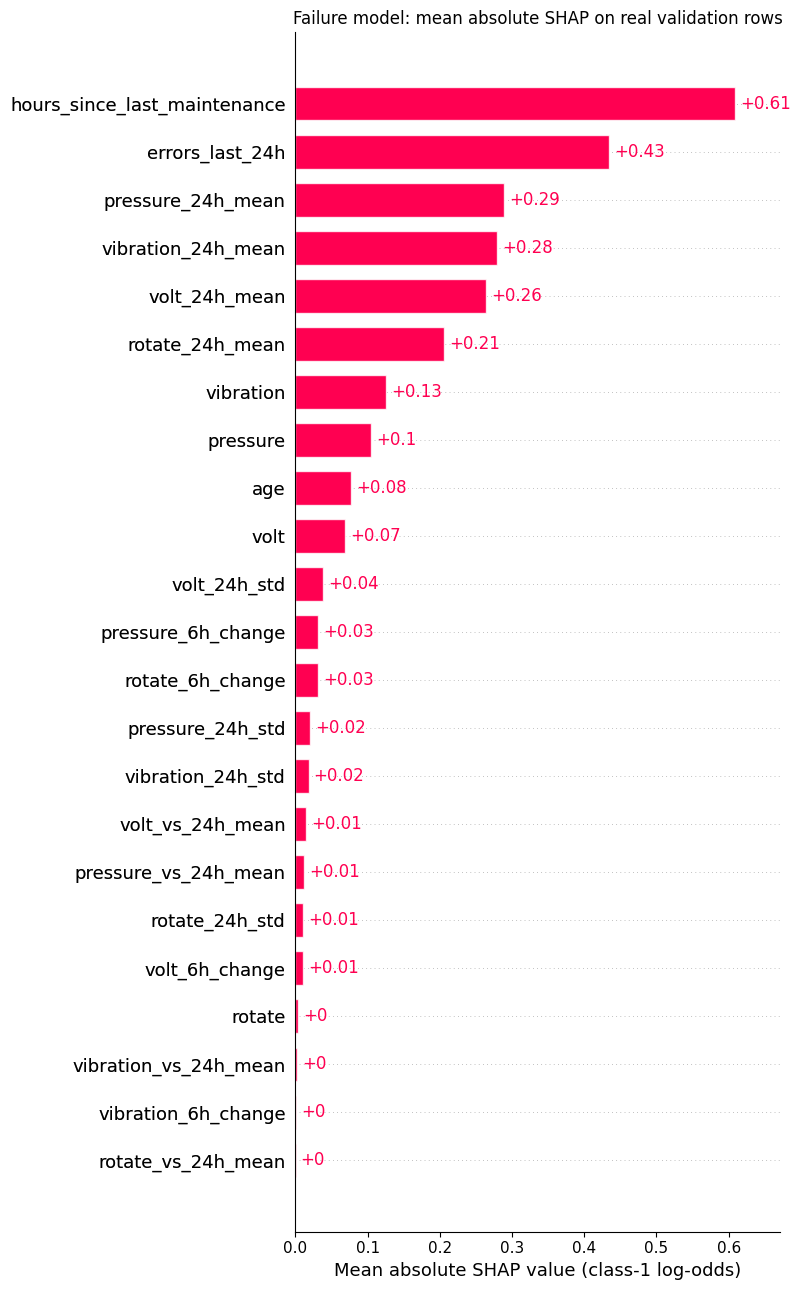

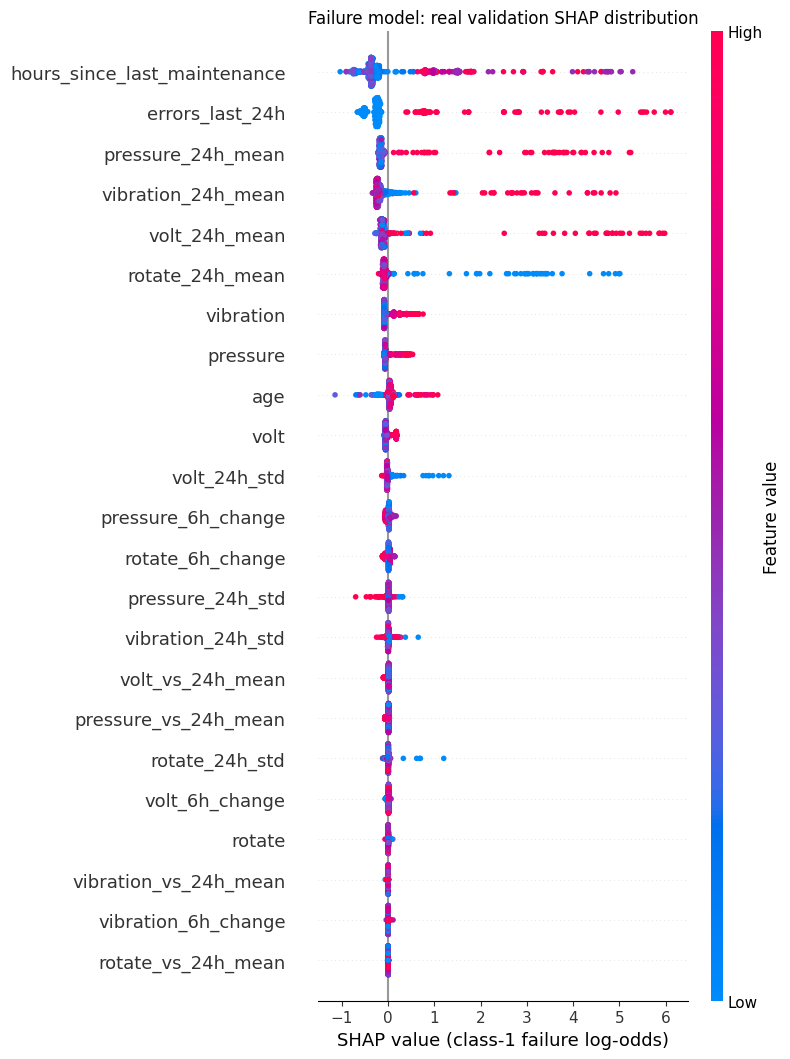

In [76]:
def _compute_failure_shap(prepared):
    """Normalize SHAP output shapes and report raw-margin reconstruction errors."""
    # Keep SHAP's native additivity check; the final section checks the sigmoid too.
    result = failure_shap_explainer(prepared, check_additivity=True, approximate=False)
    if not isinstance(result, shap.Explanation):
        raise TypeError(f"Expected modern shap.Explanation; received {type(result).__name__}")
    rows, features = prepared.shape
    raw_values = result.values
    if isinstance(raw_values, (list, tuple)):
        for class_values in raw_values:
            if np.shape(class_values) != (rows, features):
                raise ValueError("Unsupported list-based SHAP output shapes")
        raw_values = np.stack(raw_values, axis=-1)
    values = np.asarray(raw_values, dtype=float)
    bases = np.asarray(result.base_values, dtype=float)
    original_shape = values.shape
    if values.shape == (rows, features):
        # Binary XGBoost raw output is a single margin; verify its class below numerically.
        if bases.ndim == 0:
            bases = np.full(rows, float(bases))
        elif bases.shape == (rows, 1):
            bases = bases[:, 0]
        elif bases.shape != (rows,):
            raise ValueError(f"Unexpected single-output base shape: {bases.shape}")
    elif (
        values.ndim == 3
        and values.shape[:2] == (rows, features)
        and values.shape[2] in (1, len(smote_xgb.classes_))
    ):
        outputs = values.shape[2]
        output_index = 0 if outputs == 1 else list(smote_xgb.classes_).index(1)
        values = values[:, :, output_index]
        if bases.shape == (rows, outputs):
            bases = bases[:, output_index]
        elif bases.shape == (outputs,):
            bases = np.full(rows, float(bases[output_index]))
        else:
            raise ValueError(f"Unexpected multi-output base shape: {bases.shape}")
    else:
        raise ValueError(
            f"Unsupported SHAP values shape: {original_shape}; expected {rows} rows and {features} features"
        )
    margins = np.asarray(smote_xgb.predict(prepared, output_margin=True), dtype=float)
    probabilities = smote_xgb.predict_proba(prepared)[:, list(smote_xgb.classes_).index(1)].astype(
        float
    )
    reconstructed = bases + values.sum(axis=1)
    normalized = shap.Explanation(
        values=values,
        base_values=bases,
        data=prepared.to_numpy(),
        feature_names=list(feature_columns),
    )
    verification = {
        "original_values_shape": original_shape,
        "normalized_values_shape": values.shape,
        "max_margin_additivity_error": float(np.abs(reconstructed - margins).max()),
        "max_probability_reconstruction_error": float(
            np.abs(_failure_shap_expit(reconstructed) - probabilities).max()
        ),
        "output_space": "class-1 failure log-odds",
        "status": "PASS",
    }
    return normalized, verification


failure_shap_global, failure_shap_global_verification = _compute_failure_shap(
    X_failure_shap_validation
)
failure_shap_global_importance = (
    pd.DataFrame(
        {
            "Feature": feature_columns,
            "Mean absolute SHAP (log-odds)": np.abs(failure_shap_global.values).mean(axis=0),
        }
    )
    .sort_values("Mean absolute SHAP (log-odds)", ascending=False)
    .reset_index(drop=True)
)
print("Global class-1/additivity verification:", failure_shap_global_verification)
print("\nTop globally influential features on the real validation sample:")
print(failure_shap_global_importance.head(10).to_string(index=False, float_format="{:.6f}".format))
print(
    "Importance means average attribution magnitude on this sample; it does not establish causality."
)
shap.plots.bar(failure_shap_global, max_display=23, show=False)
plt.title("Failure model: mean absolute SHAP on real validation rows")
plt.xlabel("Mean absolute SHAP value (class-1 log-odds)")
plt.tight_layout()
plt.show()
shap.plots.beeswarm(failure_shap_global, max_display=23, show=False)
plt.title("Failure model: real validation SHAP distribution")
plt.xlabel("SHAP value (class-1 failure log-odds)")
plt.tight_layout()
plt.show()


In [77]:
from operator import itemgetter

_failure_shap_sensor_labels = {
    "volt": "Voltage",
    "rotate": "Rotation speed",
    "pressure": "Pressure",
    "vibration": "Vibration",
}
failure_shap_feature_labels = {
    **_failure_shap_sensor_labels,
    "age": "Machine age",
    "errors_last_24h": "Recent error activity",
    "hours_since_last_maintenance": "Time since last maintenance",
}
for _failure_shap_sensor, _failure_shap_label in _failure_shap_sensor_labels.items():
    failure_shap_feature_labels.update(
        {
            f"{_failure_shap_sensor}_24h_mean": f"Recent 24-hour average {_failure_shap_label.lower()}",
            f"{_failure_shap_sensor}_24h_std": f"Recent {_failure_shap_label.lower()} instability",
            f"{_failure_shap_sensor}_vs_24h_mean": f"{_failure_shap_label} deviation from its recent average",
            f"{_failure_shap_sensor}_6h_change": f"Six-hour {_failure_shap_label.lower()} change",
        }
    )


def _describe_failure_shap_feature(feature, value, contribution, imputed):
    sensor = feature.split("_")[0]
    sensor_label = _failure_shap_sensor_labels.get(sensor, sensor)
    if imputed:
        observation = f"{failure_shap_feature_labels[feature]} was missing; the model used the training-median value {value:.4g}"
    elif feature.endswith("_vs_24h_mean"):
        if value > 0:
            relation = "above"
        elif value < 0:
            relation = "below"
        else:
            relation = "equal to"
        observation = (
            f"{sensor_label} is {abs(value):.4g} units {relation} its recent 24-hour average"
            if value
            else f"{sensor_label} is equal to its recent 24-hour average"
        )
    elif feature.endswith("_6h_change"):
        if value > 0:
            change = "increased"
        elif value < 0:
            change = "decreased"
        else:
            change = "not changed"
        observation = (
            f"{sensor_label} has {change}"
            + (f" by {abs(value):.4g}" if value else "")
            + " over the last 6 hours"
        )
    elif feature.endswith("_24h_std"):
        observation = (
            f"Recent {sensor_label.lower()} instability: 24-hour standard deviation {value:.4g}"
        )
    elif feature.endswith("_24h_mean"):
        observation = f"Recent 24-hour average {sensor_label.lower()}: {value:.4g}"
    elif feature == "errors_last_24h":
        observation = f"Recent error activity: {value:g} events in the last 24 hours"
    elif feature == "hours_since_last_maintenance":
        observation = f"Time since last maintenance: {value:.4g} hours"
    else:
        observation = f"{failure_shap_feature_labels[feature]}: {value:.4g}"
    if contribution > 0:
        direction = "higher"
    elif contribution < 0:
        direction = "lower"
    else:
        direction = None
    return observation + (
        f"; this feature pushed the model toward {direction} predicted failure risk."
        if direction
        else "; zero SHAP contribution for this row."
    )


def _explain_failure_row(feature_row, prediction, top_n=5):
    """Share the explanation math between public inference and historical examples."""
    context = feature_row.attrs["context"]
    prepared = _prepare_failure_shap_frame(feature_row)
    explanation, verification = _compute_failure_shap(prepared)
    contributions = []
    for position, feature in enumerate(feature_columns):
        value = float(prepared.iloc[0, position])
        contribution = float(explanation.values[0, position])
        imputed = bool(pd.isna(feature_row.iloc[0, position]))
        contributions.append(
            {
                "feature": feature,
                "label": failure_shap_feature_labels[feature],
                "value": value,
                "shap_value": contribution,
                "imputed": imputed,
                "explanation": _describe_failure_shap_feature(
                    feature, value, contribution, imputed
                ),
            }
        )
    increasing = []
    decreasing = []
    for item in contributions:
        if item["shap_value"] > 0:
            increasing.append(item)
        elif item["shap_value"] < 0:
            decreasing.append(item)
    increasing = sorted(increasing, key=itemgetter("shap_value"), reverse=True)[:top_n]
    decreasing = sorted(decreasing, key=itemgetter("shap_value"))[:top_n]
    return {
        **prediction,
        "machine_id": context["machine_id"],
        "prediction_time": context["prediction_time"],
        "shap_output_space": "class-1 failure log-odds",
        "shap_base_value": float(explanation.base_values[0]),
        "model_margin": float(smote_xgb.predict(prepared, output_margin=True)[0]),
        "risk_increasing_features": increasing,
        "risk_decreasing_features": decreasing,
        "feature_contributions": contributions,
        "verification": verification,
        "numerically_saturated_sensors": list(
            feature_row.attrs.get("numerically_saturated_sensors", [])
        ),
    }


def explain_machine_failure(machine_id, volt, rotate, pressure, vibration, top_n=5):
    """Explain the frozen class-1 failure prediction with five sensor/context inputs.

    top_n controls explanation length only. SHAP values are additive log-odds
    contributions, not probability percentages, anomaly scores or physical causes.
    Uses the existing selected-machine next-hour context and frozen preprocessing.
    """
    if (
        isinstance(top_n, bool)
        or not isinstance(top_n, (int, np.integer))
        or (not 1 <= top_n <= len(feature_columns))
    ):
        raise ValueError("top_n must be an integer from 1 to 23.")
    feature_row = build_machine_features(machine_id, volt, rotate, pressure, vibration)
    prediction = predict_machine_failure(machine_id, volt, rotate, pressure, vibration)
    return _explain_failure_row(feature_row, prediction, top_n)


print("New explanation API:", inspect.signature(explain_machine_failure))
print(
    "Five public prediction inputs; top_n controls only the number of drivers shown per direction."
)


New explanation API: (machine_id, volt, rotate, pressure, vibration, top_n=5)
Five public prediction inputs; top_n controls only the number of drivers shown per direction.


### Local explanations for the original validation examples

Keep the original low-risk and high-risk validation readings and the existing
synthetic positive example. For historical readings, build features at the
reading's exact time and use the same preprocessing and explanation calculation
as public inference. SHAP values remain contributions in raw log-odds.


In [78]:
_failure_shap_real_probabilities = pd.Series(
    smote_validation_probabilities, index=validation_df.index
)
_failure_shap_low_index = _failure_shap_real_probabilities.idxmin()
_failure_shap_high_index = _failure_shap_real_probabilities.idxmax()
failure_shap_local_examples = {}
failure_shap_local_inputs = {}

for _failure_shap_case, _failure_shap_index in [
    ("Low-risk real validation replay", _failure_shap_low_index),
    ("High-risk real validation replay", _failure_shap_high_index),
]:
    _failure_shap_row = validation_df.loc[_failure_shap_index]
    _failure_shap_time = pd.to_datetime(_failure_shap_row["datetime"], utc=True)
    _failure_shap_inputs = {"machine_id": int(_failure_shap_row["machineID"])}
    for sensor in ["volt", "rotate", "pressure", "vibration"]:
        _failure_shap_inputs[sensor] = float(_failure_shap_row[sensor])

    # Use only history before this real reading; no function cloning is needed.
    _failure_shap_features = _build_machine_features_at(
        **_failure_shap_inputs, prediction_time=_failure_shap_time
    )
    _failure_shap_prepared = _prepare_failure_shap_frame(_failure_shap_features)
    _failure_shap_class = list(smote_xgb.classes_).index(1)
    _failure_shap_probability = float(
        smote_xgb.predict_proba(_failure_shap_prepared)[0, _failure_shap_class]
    )
    _failure_shap_prediction = {
        "failure": "Yes" if _failure_shap_probability >= selected_smote_threshold else "No",
        "failure_probability_percent": _failure_shap_probability * 100,
    }
    failure_shap_local_examples[_failure_shap_case] = _explain_failure_row(
        _failure_shap_features, _failure_shap_prediction
    )
    failure_shap_local_inputs[_failure_shap_case] = _failure_shap_inputs

failure_shap_local_examples["Existing synthetic positive: safety only"] = explain_machine_failure(
    **positive_case_inputs
)
failure_shap_local_inputs["Existing synthetic positive: safety only"] = dict(positive_case_inputs)

for _failure_shap_case, _failure_shap_result in failure_shap_local_examples.items():
    print(
        f"\n{_failure_shap_case}; machine {_failure_shap_result['machine_id']}; {_failure_shap_result['prediction_time']}"
    )
    print(
        f"Failure: {_failure_shap_result['failure']}; Failure Risk: {_failure_shap_result['failure_probability_percent']:.6f}%"
    )
    for _failure_shap_key, _failure_shap_heading in [
        ("risk_increasing_features", "Top risk-increasing features"),
        ("risk_decreasing_features", "Top risk-decreasing features"),
    ]:
        print(_failure_shap_heading + ":")
        for _failure_shap_driver in _failure_shap_result[_failure_shap_key]:
            print(
                f"  {_failure_shap_driver['feature']}: SHAP {_failure_shap_driver['shap_value']:+.6f} log-odds. {_failure_shap_driver['explanation']}"
            )
        if not _failure_shap_result[_failure_shap_key]:
            print("  None for this row.")
    print("Verification:", _failure_shap_result["verification"])



Low-risk real validation replay; machine 81; 2015-12-07T04:00:00+00:00
Failure: No; Failure Risk: 0.003819%
Top risk-increasing features:
  volt_vs_24h_mean: SHAP +0.006984 log-odds. Voltage is 15.87 units below its recent 24-hour average; this feature pushed the model toward higher predicted failure risk.
  pressure_vs_24h_mean: SHAP +0.006651 log-odds. Pressure is 2.305 units above its recent 24-hour average; this feature pushed the model toward higher predicted failure risk.
  vibration_vs_24h_mean: SHAP +0.000733 log-odds. Vibration is 2.565 units above its recent 24-hour average; this feature pushed the model toward higher predicted failure risk.
Top risk-decreasing features:
  hours_since_last_maintenance: SHAP -0.389714 log-odds. Time since last maintenance: 214 hours; this feature pushed the model toward lower predicted failure risk.
  age: SHAP -0.274639 log-odds. Machine age: 1; this feature pushed the model toward lower predicted failure risk.
  vibration_24h_mean: SHAP -0.

## Remaining useful life (RUL): target construction

`rul_hours` counts hours until the same machine's next recorded failure.
A failure at the reading's exact timestamp gives RUL = 0. After that event,
the countdown uses the next failure. If no future failure was observed, RUL
stays `NaN` because the remaining lifetime is unknown.

Work on `rul_df = df.copy()` so the original `df` stays unchanged.
`next_failure_time` is for inspecting the target only. Neither it nor
`rul_hours` or `failure_next_24h` belongs in a model's input features.

NumPy searches all readings for one machine together; there is no row-by-row
Python loop. The examples below show the exact-failure and unknown-tail cases.


In [79]:
# 1. Copy the data so the existing project data stays untouched.
rul_df = df.copy()
rul_failures = failures[["machineID", "datetime"]].copy()

rul_df["datetime"] = pd.to_datetime(rul_df["datetime"], errors="raise")
rul_failures["datetime"] = pd.to_datetime(rul_failures["datetime"], errors="raise")

if rul_df[["machineID", "datetime"]].isna().any().any():
    raise ValueError("RUL telemetry needs non-missing machine IDs and timestamps.")
if rul_failures[["machineID", "datetime"]].isna().any().any():
    raise ValueError("RUL failures need non-missing machine IDs and timestamps.")

# Several components can fail at the same time. That is one RUL time boundary.
rul_failures = rul_failures.drop_duplicates(["machineID", "datetime"])
rul_failures = rul_failures.sort_values(["machineID", "datetime"])

print("Telemetry rows:", len(rul_df))
print("Telemetry machines:", rul_df["machineID"].nunique())
print("Distinct machine/failure timestamps:", len(rul_failures))


Telemetry rows: 876100
Telemetry machines: 100
Distinct machine/failure timestamps: 719


In [80]:
# 2. Find the next failure for whole arrays of readings within each machine.
rul_telemetry_times = rul_df["datetime"].to_numpy(dtype="datetime64[ns]")
rul_next_failure_times = np.full(len(rul_df), np.datetime64("NaT"), dtype="datetime64[ns]")
rul_hours_values = np.full(len(rul_df), np.nan, dtype=float)
rul_machine_positions = rul_df.groupby("machineID").indices

for rul_machine_id, rul_positions in rul_machine_positions.items():
    rul_machine_times = rul_telemetry_times[rul_positions]
    rul_machine_failure_times = rul_failures.loc[
        rul_failures["machineID"] == rul_machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")

    if len(rul_machine_failure_times) == 0:
        continue  # No recorded failures: every target for this machine stays NaN.

    # "left" includes an equal timestamp, so a reading at a failure gets RUL 0.
    rul_next_indices = np.searchsorted(rul_machine_failure_times, rul_machine_times, side="left")
    rul_has_next_failure = rul_next_indices < len(rul_machine_failure_times)
    rul_known_positions = rul_positions[rul_has_next_failure]
    rul_matched_failure_times = rul_machine_failure_times[rul_next_indices[rul_has_next_failure]]
    rul_time_until_failure = rul_matched_failure_times - rul_machine_times[rul_has_next_failure]

    rul_next_failure_times[rul_known_positions] = rul_matched_failure_times
    rul_hours_values[rul_known_positions] = rul_time_until_failure / np.timedelta64(1, "h")

# Positional assignment preserves the original row order and index.
rul_df["next_failure_time"] = rul_next_failure_times
rul_df["rul_hours"] = rul_hours_values


In [81]:
# 3. Summarize the target boundaries; validity is checked in the final section.
rul_known_rows = rul_df["rul_hours"].notna()
rul_known_hours = rul_df.loc[rul_known_rows, "rul_hours"]

# Summarize the already-verified boundaries without searching every machine again.
rul_exact_match_count = int((rul_known_hours == 0).sum())
rul_first_failure_times = rul_failures.groupby("machineID")["datetime"].min()
rul_first_failure_for_row = rul_df["machineID"].map(rul_first_failure_times)
rul_has_recorded_failure = rul_first_failure_for_row.notna()
rul_uses_later_failure = rul_df["next_failure_time"] > rul_first_failure_for_row
rul_after_previous_count = int(rul_uses_later_failure.sum())
rul_after_final_count = int((~rul_known_rows & rul_has_recorded_failure).sum())
rul_no_failure_count = int((~rul_has_recorded_failure).sum())

print("known RUL is finite, non-negative, and equals the time difference in hours.")
print(f"exact failure timestamps have RUL 0 ({rul_exact_match_count:,} rows).")
print("all assigned failure timestamps belong to the same machine.")
print(f"first eligible failure used; {rul_after_previous_count:,} rows follow an earlier failure.")
print(f"rows after the final failure have unknown RUL ({rul_after_final_count:,} rows).")
print(f"machines without recorded failures retain NaN ({rul_no_failure_count:,} rows).")
print("row order, index, original df columns, and both feature lists preserved.")


known RUL is finite, non-negative, and equals the time difference in hours.
exact failure timestamps have RUL 0 (719 rows).
all assigned failure timestamps belong to the same machine.
first eligible failure used; 687,627 rows follow an earlier failure.
rows after the final failure have unknown RUL (103,224 rows).
machines without recorded failures retain NaN (17,522 rows).
row order, index, original df columns, and both feature lists preserved.


In [82]:
# 4. Describe only known targets; unknown targets remain NaN in rul_df.
rul_known_hours = rul_df["rul_hours"].dropna()
rul_total_rows = len(rul_df)
rul_known_count = len(rul_known_hours)
rul_unknown_count = int(rul_df["rul_hours"].isna().sum())

print(f"Total rows:       {rul_total_rows:,}")
print(f"Known RUL rows:   {rul_known_count:,}")
print(f"Unknown RUL rows: {rul_unknown_count:,}")
print(f"Minimum known RUL: {rul_known_hours.min():,.2f} hours")
print(f"Maximum known RUL: {rul_known_hours.max():,.2f} hours")
print(f"Mean known RUL:    {rul_known_hours.mean():,.2f} hours")
print(f"Median known RUL:  {rul_known_hours.median():,.2f} hours")

print("\nKnown RUL percentiles (hours):")
rul_percentile_levels = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
rul_percentiles = rul_known_hours.quantile(rul_percentile_levels)
for rul_percentile, rul_value in rul_percentiles.items():
    print(f"{rul_percentile:.0%}: {rul_value:,.2f}")


Total rows:       876,100
Known RUL rows:   755,354
Unknown RUL rows: 120,746
Minimum known RUL: 0.00 hours
Maximum known RUL: 6,479.00 hours
Mean known RUL:    911.01 hours
Median known RUL:  626.00 hours

Known RUL percentiles (hours):
25%: 273.00
50%: 626.00
75%: 1,210.00
90%: 2,022.00
95%: 2,834.00
99%: 4,783.00


In [83]:
# 5. Show the boundary around a failure and the tail after the final failure.
rul_example_columns = ["machineID", "datetime", "next_failure_time", "rul_hours"]
rul_example_machine_ids = (
    rul_failures.loc[rul_failures["machineID"].isin(rul_df["machineID"]), "machineID"]
    .drop_duplicates()
    .head(3)
)

for rul_example_machine_id in rul_example_machine_ids:
    rul_example_rows = rul_df.loc[
        rul_df["machineID"] == rul_example_machine_id, rul_example_columns
    ].sort_values("datetime")
    rul_example_failures = rul_failures.loc[
        rul_failures["machineID"] == rul_example_machine_id, "datetime"
    ]
    rul_visible_failures = rul_example_failures.loc[
        (rul_example_failures >= rul_example_rows["datetime"].min())
        & (rul_example_failures < rul_example_rows["datetime"].max())
    ]

    print(f"\nMachine {rul_example_machine_id}")
    if not rul_visible_failures.empty:
        rul_example_failure = rul_visible_failures.iloc[0]
        rul_window_start = rul_example_failure - pd.Timedelta(hours=2)
        rul_window_end = rul_example_failure + pd.Timedelta(hours=2)
        rul_boundary_rows = rul_example_rows.loc[
            (rul_example_rows["datetime"] >= rul_window_start)
            & (rul_example_rows["datetime"] <= rul_window_end)
        ]
        print(f"Before, at, and after the failure at {rul_example_failure}:")
        print(rul_boundary_rows.to_string(index=False))
    else:
        print("No failure boundary lies within this machine's telemetry period.")

    rul_final_failure = rul_example_failures.iloc[-1]
    rul_tail_rows = rul_example_rows.loc[rul_example_rows["datetime"] > rul_final_failure].head(2)
    print(f"After the final recorded failure at {rul_final_failure}:")
    if rul_tail_rows.empty:
        print("No telemetry rows available after the final recorded failure.")
    else:
        print(rul_tail_rows.to_string(index=False))



Machine 1
Before, at, and after the failure at 2015-01-05 06:00:00:
 machineID            datetime   next_failure_time  rul_hours
         1 2015-01-05 04:00:00 2015-01-05 06:00:00        2.0
         1 2015-01-05 05:00:00 2015-01-05 06:00:00        1.0
         1 2015-01-05 06:00:00 2015-01-05 06:00:00        0.0
         1 2015-01-05 07:00:00 2015-03-06 06:00:00     1439.0
         1 2015-01-05 08:00:00 2015-03-06 06:00:00     1438.0
After the final recorded failure at 2015-12-16 06:00:00:
 machineID            datetime next_failure_time  rul_hours
         1 2015-12-16 07:00:00               NaT        NaN
         1 2015-12-16 08:00:00               NaT        NaN

Machine 2
Before, at, and after the failure at 2015-03-19 06:00:00:
 machineID            datetime   next_failure_time  rul_hours
         2 2015-03-19 04:00:00 2015-03-19 06:00:00        2.0
         2 2015-03-19 05:00:00 2015-03-19 06:00:00        1.0
         2 2015-03-19 06:00:00 2015-03-19 06:00:00        0.0
     

In [84]:
# This is the end of this phase.
print("RUL TARGET CONSTRUCTION COMPLETE")
print(f"Known targets: {rul_known_count:,}; unknown targets kept as NaN: {rul_unknown_count:,}.")
print("Result: rul_df with rul_hours and the inspection-only next_failure_time column.")


RUL TARGET CONSTRUCTION COMPLETE
Known targets: 755,354; unknown targets kept as NaN: 120,746.
Result: rul_df with rul_hours and the inspection-only next_failure_time column.


## Basic RUL regression baselines

Use only voltage, rotation, pressure, vibration, and age. Both regressors reuse
the existing machine split and learn the original RUL target in hours.

Rows with unknown `rul_hours` stay `NaN` in `rul_df` and are excluded from this
experiment. The errors therefore describe readings with an observed future failure.

MAE and RMSE are in hours; lower is better. Higher R² is better. A negative R²
means worse squared error than predicting that evaluated split's mean target.
Test features use the training imputer, but test predictions and evaluation are
left for a later phase. No final production model is selected here.

The saved numeric outputs are retained from the verified baseline run.
This readability cleanup did not rerun any training cells.


In [85]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Define the inputs once so both baselines receive the same five columns.
rul_basic_features = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "age",
]

print("RUL features:", rul_basic_features)


RUL features: ['volt', 'rotate', 'pressure', 'vibration', 'age']


### 1–2. Keep known targets and reuse the machine split

Keep `machineID` only to assign rows to the existing populations. The summary
shows assigned machines and machines with known RUL separately: a machine
without an observed future failure contributes no known-target rows.


In [86]:
# 1. Exclude unknown targets without changing their NaN values in rul_df.
rul_basic_known_mask = rul_df["rul_hours"].notna()
rul_basic_data_columns = ["machineID"] + rul_basic_features + ["rul_hours"]
rul_known_df = rul_df.loc[rul_basic_known_mask, rul_basic_data_columns].copy()

print("Known RUL rows retained:", len(rul_known_df))
print("Unknown RUL rows excluded, still NaN in rul_df:", int((~rul_basic_known_mask).sum()))

# 2. Reuse the original machine IDs; do not make another random split.

rul_train_df = rul_known_df.loc[rul_known_df["machineID"].isin(train_ids)].copy()
rul_validation_df = rul_known_df.loc[rul_known_df["machineID"].isin(validation_ids)].copy()
rul_test_df = rul_known_df.loc[rul_known_df["machineID"].isin(test_ids)].copy()

rul_basic_split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Assigned machines": [len(train_ids), len(validation_ids), len(test_ids)],
        "Machines with known RUL": [
            rul_train_df["machineID"].nunique(),
            rul_validation_df["machineID"].nunique(),
            rul_test_df["machineID"].nunique(),
        ],
        "Known RUL rows": [len(rul_train_df), len(rul_validation_df), len(rul_test_df)],
    }
)
print(rul_basic_split_summary.to_string(index=False))

if len(rul_train_df) < 2 or len(rul_validation_df) < 2 or len(rul_test_df) < 2:
    raise ValueError("Each existing split needs at least two known RUL rows for this experiment.")


Known RUL rows retained: 755354
Unknown RUL rows excluded, still NaN in rul_df: 120746
     Split  Assigned machines  Machines with known RUL  Known RUL rows
     Train                 70                       69          535173
Validation                 15                       15          115359
      Test                 15                       14          104822


### 3–5. Create X and y, fit the training imputer, and transform each split

Treat infinite feature values as missing and keep every known-target row.
Fit a separate median imputer on training features only. Stop if a training
feature has no finite values, because its median cannot be estimated.


In [87]:
# 3. X contains only the five inputs; y contains the RUL target.
X_rul_train_basic = rul_train_df.loc[:, rul_basic_features].copy()
y_rul_train = rul_train_df["rul_hours"].copy()
X_rul_validation_basic = rul_validation_df.loc[:, rul_basic_features].copy()
y_rul_validation = rul_validation_df["rul_hours"].copy()
X_rul_test_basic = rul_test_df.loc[:, rul_basic_features].copy()
y_rul_test = rul_test_df["rul_hours"].copy()

for rul_basic_split, rul_basic_inputs in [
    ("Train", X_rul_train_basic),
    ("Validation", X_rul_validation_basic),
    ("Test", X_rul_test_basic),
]:
    rul_basic_nan_counts = rul_basic_inputs.isna().sum()
    rul_basic_infinite_counts = np.isinf(rul_basic_inputs).sum()
    rul_basic_feature_checks = pd.DataFrame(
        {
            "NaN values": rul_basic_nan_counts,
            "Infinite values": rul_basic_infinite_counts,
        }
    )
    print(f"\n{rul_basic_split} feature checks:")
    print(rul_basic_feature_checks.to_string())

# These replacements affect only the separate RUL feature copies.
X_rul_train_basic = X_rul_train_basic.replace([np.inf, -np.inf], np.nan)
X_rul_validation_basic = X_rul_validation_basic.replace([np.inf, -np.inf], np.nan)
X_rul_test_basic = X_rul_test_basic.replace([np.inf, -np.inf], np.nan)

rul_basic_empty_training_features = X_rul_train_basic.columns[
    X_rul_train_basic.isna().all()
].tolist()
if rul_basic_empty_training_features:
    raise ValueError(f"Cannot compute training medians for: {rul_basic_empty_training_features}")

# 4. Learn replacement values from training features only.
rul_basic_imputer = SimpleImputer(strategy="median")
rul_basic_imputer.fit(X_rul_train_basic)

# 5. Apply those same training medians to all three splits.
rul_basic_train_imputed = rul_basic_imputer.transform(X_rul_train_basic)
rul_basic_validation_imputed = rul_basic_imputer.transform(X_rul_validation_basic)
rul_basic_test_imputed = rul_basic_imputer.transform(X_rul_test_basic)

# Restore the same column order and row indexes after transformation.
X_rul_train_basic = pd.DataFrame(
    rul_basic_train_imputed, columns=rul_basic_features, index=y_rul_train.index
)
X_rul_validation_basic = pd.DataFrame(
    rul_basic_validation_imputed, columns=rul_basic_features, index=y_rul_validation.index
)
X_rul_test_basic = pd.DataFrame(
    rul_basic_test_imputed, columns=rul_basic_features, index=y_rul_test.index
)

print("\nPrepared five RUL features; no known-target rows dropped.")
print("Median imputer fitted only on RUL training features.")



Train feature checks:
           NaN values  Infinite values
volt                0                0
rotate              0                0
pressure            0                0
vibration           0                0
age                 0                0

Validation feature checks:
           NaN values  Infinite values
volt                0                0
rotate              0                0
pressure            0                0
vibration           0                0
age                 0                0

Test feature checks:
           NaN values  Infinite values
volt                0                0
rotate              0                0
pressure            0                0
vibration           0                0
age                 0                0

Prepared five RUL features; no known-target rows dropped.
Median imputer fitted only on RUL training features.


### 6–8. Linear Regression: fit, predict, and evaluate


In [88]:
# 6. Fit the baseline using training data only.
rul_linear_model = LinearRegression()
rul_linear_model.fit(X_rul_train_basic, y_rul_train)

# 7. Predict the raw RUL values; keep any negative predictions.
rul_linear_train_predictions = rul_linear_model.predict(X_rul_train_basic)
rul_linear_validation_predictions = rul_linear_model.predict(X_rul_validation_basic)

# 8. Calculate the same metrics separately for training and validation.
rul_linear_metric_rows = []
for rul_basic_split, rul_basic_actual, rul_basic_predictions in [
    ("Train", y_rul_train, rul_linear_train_predictions),
    ("Validation", y_rul_validation, rul_linear_validation_predictions),
]:
    rul_basic_mae = mean_absolute_error(rul_basic_actual, rul_basic_predictions)
    rul_basic_mse = mean_squared_error(rul_basic_actual, rul_basic_predictions)
    rul_basic_rmse = np.sqrt(rul_basic_mse)
    rul_basic_r2 = r2_score(rul_basic_actual, rul_basic_predictions)
    rul_basic_negative_count = int((rul_basic_predictions < 0).sum())
    rul_basic_minimum_prediction = float(rul_basic_predictions.min())
    rul_linear_metric_rows.append(
        {
            "Split": rul_basic_split,
            "MAE (hours)": rul_basic_mae,
            "RMSE (hours)": rul_basic_rmse,
            "R²": rul_basic_r2,
            "Negative predictions": rul_basic_negative_count,
            "Minimum prediction (hours)": rul_basic_minimum_prediction,
        }
    )

rul_linear_metrics = pd.DataFrame(rul_linear_metric_rows).set_index("Split")
print("Linear Regression — raw predictions:")
print(rul_linear_metrics.round(3).to_string())
print("Negative predictions, if present, are reported without clipping.")


Linear Regression — raw predictions:
            MAE (hours)  RMSE (hours)     R²  Negative predictions  Minimum prediction (hours)
Split                                                                                         
Train           676.568       971.942  0.047                     0                     453.095
Validation      656.684       874.148  0.071                     0                     532.336
Negative predictions, if present, are reported without clipping.


### 9–11. Basic XGBoost Regressor: fit, predict, and evaluate

Keep the original configuration: 200 trees, maximum depth 3, learning rate
0.05, and 80% row and feature sampling. This is one baseline run without
parameter search or early stopping. Targets and predictions stay in hours.


In [89]:
# 9. Fit the existing baseline configuration using training data only.
rul_xgb_basic = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)
rul_xgb_basic.fit(X_rul_train_basic, y_rul_train)

# 10. Predict training and validation RUL without clipping.
rul_xgb_train_predictions = rul_xgb_basic.predict(X_rul_train_basic)
rul_xgb_validation_predictions = rul_xgb_basic.predict(X_rul_validation_basic)

# 11. Use exactly the same metrics as Linear Regression.
rul_xgb_metric_rows = []
for rul_basic_split, rul_basic_actual, rul_basic_predictions in [
    ("Train", y_rul_train, rul_xgb_train_predictions),
    ("Validation", y_rul_validation, rul_xgb_validation_predictions),
]:
    rul_basic_mae = mean_absolute_error(rul_basic_actual, rul_basic_predictions)
    rul_basic_mse = mean_squared_error(rul_basic_actual, rul_basic_predictions)
    rul_basic_rmse = np.sqrt(rul_basic_mse)
    rul_basic_r2 = r2_score(rul_basic_actual, rul_basic_predictions)
    rul_basic_negative_count = int((rul_basic_predictions < 0).sum())
    rul_basic_minimum_prediction = float(rul_basic_predictions.min())
    rul_xgb_metric_rows.append(
        {
            "Split": rul_basic_split,
            "MAE (hours)": rul_basic_mae,
            "RMSE (hours)": rul_basic_rmse,
            "R²": rul_basic_r2,
            "Negative predictions": rul_basic_negative_count,
            "Minimum prediction (hours)": rul_basic_minimum_prediction,
        }
    )

rul_xgb_metrics = pd.DataFrame(rul_xgb_metric_rows).set_index("Split")
print("Basic XGBoost Regressor — raw predictions:")
print(rul_xgb_metrics.round(3).to_string())
print("Negative predictions, if present, are reported without clipping.")


Basic XGBoost Regressor — raw predictions:
            MAE (hours)  RMSE (hours)     R²  Negative predictions  Minimum prediction (hours)
Split                                                                                         
Train           659.317       936.175  0.116                     0                      33.644
Validation      647.285       936.642 -0.066                     0                      32.162
Negative predictions, if present, are reported without clipping.


### 12–13. Compare validation results and check the training gap

Compare MAE first, then RMSE and R². Flag validation MAE above 1.5 times
training MAE as possible overfitting. This is the existing inspection rule,
not a statistical test; different machines can also produce a gap.


In [90]:
# 12. Put both baselines in one table; all errors are in hours.
rul_basic_comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Basic XGBoost Regressor"],
        "Train MAE": [
            rul_linear_metrics.loc["Train", "MAE (hours)"],
            rul_xgb_metrics.loc["Train", "MAE (hours)"],
        ],
        "Validation MAE": [
            rul_linear_metrics.loc["Validation", "MAE (hours)"],
            rul_xgb_metrics.loc["Validation", "MAE (hours)"],
        ],
        "Validation RMSE": [
            rul_linear_metrics.loc["Validation", "RMSE (hours)"],
            rul_xgb_metrics.loc["Validation", "RMSE (hours)"],
        ],
        "Validation R²": [
            rul_linear_metrics.loc["Validation", "R²"],
            rul_xgb_metrics.loc["Validation", "R²"],
        ],
    }
)
print("Baseline comparison (MAE and RMSE in hours):")
print(rul_basic_comparison.round(3).to_string(index=False))

rul_basic_linear_validation_mae = rul_linear_metrics.loc["Validation", "MAE (hours)"]
rul_basic_xgb_validation_mae = rul_xgb_metrics.loc["Validation", "MAE (hours)"]
if rul_basic_linear_validation_mae < rul_basic_xgb_validation_mae:
    print("\nLinear Regression currently performs better on validation MAE.")
elif rul_basic_xgb_validation_mae < rul_basic_linear_validation_mae:
    print("\nBasic XGBoost Regressor currently performs better on validation MAE.")
else:
    print("\nThe two baselines have equal validation MAE.")

rul_basic_linear_validation_rmse = rul_linear_metrics.loc["Validation", "RMSE (hours)"]
rul_basic_xgb_validation_rmse = rul_xgb_metrics.loc["Validation", "RMSE (hours)"]
if rul_basic_linear_validation_rmse < rul_basic_xgb_validation_rmse:
    print("Linear Regression has lower validation RMSE and higher validation R².")
elif rul_basic_xgb_validation_rmse < rul_basic_linear_validation_rmse:
    print("Basic XGBoost Regressor has lower validation RMSE and higher validation R².")
else:
    print("The two baselines have equal validation RMSE and R².")

# 13. Inspect the training/validation gap without tuning either model.
print("\nTraining versus validation MAE:")
for rul_basic_row_index, rul_basic_row in rul_basic_comparison.iterrows():
    rul_basic_model_name = rul_basic_row["Model"]
    rul_basic_train_mae = rul_basic_row["Train MAE"]
    rul_basic_validation_mae = rul_basic_row["Validation MAE"]
    rul_basic_mae_gap = rul_basic_validation_mae - rul_basic_train_mae
    print(
        f"{rul_basic_model_name}: train {rul_basic_train_mae:.3f} h; "
        f"validation {rul_basic_validation_mae:.3f} h; gap {rul_basic_mae_gap:+.3f} h."
    )
    if rul_basic_validation_mae > 1.5 * rul_basic_train_mae:
        print("Possible overfitting: validation MAE exceeds 1.5 times training MAE.")
    else:
        print("No dramatic training advantage by this rule; this does not rule out overfitting.")

print("\nThis comparison uses validation only. No final RUL model has been selected.")


Baseline comparison (MAE and RMSE in hours):
                  Model  Train MAE  Validation MAE  Validation RMSE  Validation R²
      Linear Regression    676.568         656.684          874.148          0.071
Basic XGBoost Regressor    659.317         647.285          936.642         -0.066

Basic XGBoost Regressor currently performs better on validation MAE.
Linear Regression has lower validation RMSE and higher validation R².

Training versus validation MAE:
Linear Regression: train 676.568 h; validation 656.684 h; gap -19.884 h.
No dramatic training advantage by this rule; this does not rule out overfitting.
Basic XGBoost Regressor: train 659.317 h; validation 647.285 h; gap -12.032 h.
No dramatic training advantage by this rule; this does not rule out overfitting.

This comparison uses validation only. No final RUL model has been selected.


The baseline comparison ends here. The final integration check below uses
representative validation inputs without fitting models or evaluating RUL test data.


## Final Integration Check

Run these checks after the notebook's modelling sections. They use the existing
fitted objects and a representative validation machine. No fitting, threshold
selection, parameter tuning, or RUL test evaluation happens here.


In [91]:
# 1. Whole machines must belong to only one split.
assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)
print("PASS: machine splits are separate")

# 2. Targets and future information stay outside every input schema.
integration_excluded_features = {
    "machineID",
    "datetime",
    "failure_next_24h",
    "rul_hours",
    "next_failure_time",
    "failure_count",
    "failure_group",
    "split",
    "anomaly_score",
    "shap_values",
}
for integration_schema in [feature_columns, anomaly_feature_columns, rul_basic_features]:
    assert integration_excluded_features.isdisjoint(integration_schema)
assert (
    list(feature_imputer.feature_names_in_) == feature_columns == list(smote_xgb.feature_names_in_)
)
assert (
    list(anomaly_imputer.feature_names_in_)
    == anomaly_feature_columns
    == list(isolation_forest.feature_names_in_)
)
assert selected_smote_threshold == 0.60
print("PASS: input schemas are safe and the failure threshold is 0.60")

# Use one validation machine's latest sensors in the public next-hour interface.
integration_machine_id = int(sorted(validation_ids)[0])
integration_machine_rows = telemetry.loc[telemetry["machineID"] == integration_machine_id]
integration_reading = integration_machine_rows.sort_values("datetime").iloc[-1]
integration_inputs = {"machine_id": integration_machine_id}
for integration_sensor in ["volt", "rotate", "pressure", "vibration"]:
    integration_inputs[integration_sensor] = float(integration_reading[integration_sensor])

# 3. Check the public failure probability and label.
integration_failure = predict_machine_failure(**integration_inputs)
integration_probability = integration_failure["failure_probability_percent"] / 100
assert np.isfinite(integration_probability) and 0 <= integration_probability <= 1
assert integration_failure["failure"] in ["Yes", "No"]
assert (integration_failure["failure"] == "Yes") == (
    integration_probability >= selected_smote_threshold
)
print("PASS: failure inference works")

# 4. The anomaly score is relative; positive scores use the anomaly label.
integration_anomaly = predict_machine_anomaly(**integration_inputs)
assert np.isfinite(integration_anomaly["anomaly_score"])
assert integration_anomaly["anomaly_status"] in ["Normal", "Anomaly Detected"]
assert integration_anomaly["anomaly_detected"] in ["Yes", "No"]
assert (integration_anomaly["anomaly_status"] == "Anomaly Detected") == (
    integration_anomaly["anomaly_score"] > 0
)
print("PASS: anomaly inference works")

# 5. SHAP contributions reconstruct log-odds, then sigmoid gives the same probability.
integration_explanation = explain_machine_failure(**integration_inputs)
integration_margin = integration_explanation["shap_base_value"]
for integration_contribution in integration_explanation["feature_contributions"]:
    integration_margin += integration_contribution["shap_value"]
np.testing.assert_allclose(
    integration_margin, integration_explanation["model_margin"], rtol=1e-5, atol=2e-5
)
np.testing.assert_allclose(
    _failure_shap_expit(integration_margin), integration_probability, rtol=1e-5, atol=2e-6
)
print("PASS: SHAP reconstruction works")

# 6. Unknown future lifetimes stay NaN; known targets cannot be negative.
integration_known_rul = rul_df.loc[rul_df["rul_hours"].notna(), "rul_hours"]
integration_unknown_rul = rul_df["next_failure_time"].isna()
assert np.isfinite(integration_known_rul).all() and (integration_known_rul >= 0).all()
assert rul_df.loc[integration_unknown_rul, "rul_hours"].isna().all()
print("PASS: RUL target is valid")

# 7. Reuse the RUL imputer and both fitted models on a small validation batch.
integration_rul_raw = rul_validation_df.loc[:, rul_basic_features].head(5)
integration_rul_raw = integration_rul_raw.replace([np.inf, -np.inf], np.nan)
integration_rul_prepared = pd.DataFrame(
    rul_basic_imputer.transform(integration_rul_raw),
    index=integration_rul_raw.index,
    columns=rul_basic_features,
)
for integration_rul_model in [rul_linear_model, rul_xgb_basic]:
    assert list(integration_rul_model.feature_names_in_) == rul_basic_features
    integration_rul_predictions = integration_rul_model.predict(integration_rul_prepared)
    assert np.isfinite(integration_rul_predictions).all()
print("PASS: RUL baseline inference works")
print("FULL NOTEBOOK READABILITY CLEANUP COMPLETE")


PASS: machine splits are separate
PASS: input schemas are safe and the failure threshold is 0.60
PASS: failure inference works
PASS: anomaly inference works
PASS: SHAP reconstruction works
PASS: RUL target is valid
PASS: RUL baseline inference works
FULL NOTEBOOK READABILITY CLEANUP COMPLETE


## Contextual RUL regression experiment

Compare the five basic inputs with 23 contextual inputs on exactly the same
known-target rows and machine populations. Reuse the existing targets and basic
metrics. Fit a separate imputer and two new regressors.

The contextual columns already exist in `rul_df`. Their 24-hour statistics
include the current reading and up to 23 earlier readings of the same machine.
Six-hour changes use that machine's earlier reading. Error counts use the past
24 hours through the current timestamp; maintenance uses the latest event at
or before that timestamp. Initial unavailable standard deviations and six-hour
changes retain the existing feature construction's zero fill.

Targets and predictions remain in hours. Test inputs are prepared for later
use; this experiment compares training and validation results only.


In [92]:
# 1. Use a separate feature list for this experiment.
rul_context_features = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "age",
    "errors_last_24h",
    "hours_since_last_maintenance",

    "volt_24h_mean",
    "rotate_24h_mean",
    "pressure_24h_mean",
    "vibration_24h_mean",

    "volt_24h_std",
    "rotate_24h_std",
    "pressure_24h_std",
    "vibration_24h_std",

    "volt_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "vibration_vs_24h_mean",

    "volt_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "vibration_6h_change",
]

# Targets and future information must stay outside the model inputs.
rul_context_excluded_features = {
    "machineID", "datetime", "failure_next_24h", "rul_hours",
    "next_failure_time", "anomaly_score", "shap_values",
}
assert rul_context_excluded_features.isdisjoint(rul_context_features)
print("Contextual RUL feature count:", len(rul_context_features))


Contextual RUL feature count: 23


### 1. Create X for the same rows; reuse the existing y

The basic experiment's target indexes identify the exact known-target rows in
each machine split. Selecting with those indexes preserves both row membership
and order. Keep `y_rul_train`, `y_rul_validation`, and `y_rul_test` as they are.


In [93]:
# 2. Select contextual inputs using the basic experiment's target indexes.
X_rul_train_context = rul_df.loc[y_rul_train.index, rul_context_features].copy()
X_rul_validation_context = rul_df.loc[y_rul_validation.index, rul_context_features].copy()
X_rul_test_context = rul_df.loc[y_rul_test.index, rul_context_features].copy()

# Check alignment once where the model inputs are created.
for rul_context_inputs, rul_context_target in [
    (X_rul_train_context, y_rul_train),
    (X_rul_validation_context, y_rul_validation),
    (X_rul_test_context, y_rul_test),
]:
    assert rul_context_inputs.index.equals(rul_context_target.index)
    assert list(rul_context_inputs.columns) == rul_context_features

rul_context_split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Assigned machines": [len(train_ids), len(validation_ids), len(test_ids)],
        "Known RUL rows": [
            len(X_rul_train_context),
            len(X_rul_validation_context),
            len(X_rul_test_context),
        ],
    }
)
print(rul_context_split_summary.to_string(index=False))


     Split  Assigned machines  Known RUL rows
     Train                 70          535173
Validation                 15          115359
      Test                 15          104822


### 2. Fit a separate training imputer and transform each split

Treat infinite values as missing. Learn replacement medians from contextual
training features, then apply those same values to every split. Keep all rows.


In [94]:
# 3. Prepare only the new contextual feature copies.
X_rul_train_context = X_rul_train_context.replace([np.inf, -np.inf], np.nan)
X_rul_validation_context = X_rul_validation_context.replace([np.inf, -np.inf], np.nan)
X_rul_test_context = X_rul_test_context.replace([np.inf, -np.inf], np.nan)

rul_context_missing_counts = pd.DataFrame(
    {
        "Train": X_rul_train_context.isna().sum(),
        "Validation": X_rul_validation_context.isna().sum(),
        "Test": X_rul_test_context.isna().sum(),
    }
)
print("Missing values to impute (including any infinite values):")
print(rul_context_missing_counts.to_string())

if X_rul_train_context.isna().all().any():
    raise ValueError("A contextual training feature has no finite values for its median.")

# 4. Fit only on training inputs, using a new imputer.
rul_context_imputer = SimpleImputer(strategy="median")
rul_context_imputer.fit(X_rul_train_context)

rul_context_train_imputed = rul_context_imputer.transform(X_rul_train_context)
rul_context_validation_imputed = rul_context_imputer.transform(X_rul_validation_context)
rul_context_test_imputed = rul_context_imputer.transform(X_rul_test_context)

# Preserve the declared column order and the existing target indexes.
X_rul_train_context = pd.DataFrame(
    rul_context_train_imputed, columns=rul_context_features, index=y_rul_train.index
)
X_rul_validation_context = pd.DataFrame(
    rul_context_validation_imputed, columns=rul_context_features, index=y_rul_validation.index
)
X_rul_test_context = pd.DataFrame(
    rul_context_test_imputed, columns=rul_context_features, index=y_rul_test.index
)
print("Contextual inputs prepared using training medians; all selected rows retained.")


Missing values to impute (including any infinite values):
                              Train  Validation  Test
volt                              0           0     0
rotate                            0           0     0
pressure                          0           0     0
vibration                         0           0     0
age                               0           0     0
errors_last_24h                   0           0     0
hours_since_last_maintenance      0           0     0
volt_24h_mean                     0           0     0
rotate_24h_mean                   0           0     0
pressure_24h_mean                 0           0     0
vibration_24h_mean                0           0     0
volt_24h_std                      0           0     0
rotate_24h_std                    0           0     0
pressure_24h_std                  0           0     0
vibration_24h_std                 0           0     0
volt_vs_24h_mean                  0           0     0
rotate_vs_24h_mean      

### 3. Contextual Linear Regression: fit, predict, and evaluate

Use standard Linear Regression, as in the basic baseline. Evaluate raw training
and validation predictions with the same metrics; retain any negative outputs.


In [95]:
# 5. Train the new Linear Regression model on contextual training inputs.
rul_linear_context_model = LinearRegression()
rul_linear_context_model.fit(X_rul_train_context, y_rul_train)

rul_linear_context_train_predictions = rul_linear_context_model.predict(X_rul_train_context)
rul_linear_context_validation_predictions = rul_linear_context_model.predict(
    X_rul_validation_context
)

rul_linear_context_metric_rows = []
for rul_context_split, rul_context_actual, rul_context_predictions in [
    ("Train", y_rul_train, rul_linear_context_train_predictions),
    ("Validation", y_rul_validation, rul_linear_context_validation_predictions),
]:
    rul_context_mae = mean_absolute_error(rul_context_actual, rul_context_predictions)
    rul_context_mse = mean_squared_error(rul_context_actual, rul_context_predictions)
    rul_context_rmse = np.sqrt(rul_context_mse)
    rul_context_r2 = r2_score(rul_context_actual, rul_context_predictions)
    rul_context_negative_count = int((rul_context_predictions < 0).sum())
    rul_context_minimum_prediction = float(rul_context_predictions.min())
    rul_linear_context_metric_rows.append(
        {
            "Split": rul_context_split,
            "MAE (hours)": rul_context_mae,
            "RMSE (hours)": rul_context_rmse,
            "R²": rul_context_r2,
            "Negative predictions": rul_context_negative_count,
            "Minimum prediction (hours)": rul_context_minimum_prediction,
        }
    )

rul_linear_context_metrics = pd.DataFrame(rul_linear_context_metric_rows).set_index("Split")
print("Contextual Linear Regression: raw predictions")
print(rul_linear_context_metrics.round(3).to_string())


Contextual Linear Regression: raw predictions
            MAE (hours)  RMSE (hours)     R²  Negative predictions  Minimum prediction (hours)
Split                                                                                         
Train           670.061       963.380  0.064                  1177                    -569.699
Validation      645.762       868.741  0.083                   836                    -470.497


### 4. Contextual XGBoost: use the basic model's parameters

Keep 200 trees, depth 3, learning rate 0.05, and 80% row and feature sampling,
with the same regression objective, histogram tree method, seed, and worker
count. This compares features without parameter tuning or early stopping.


In [96]:
# 6. Use the same configuration as rul_xgb_basic.
rul_xgb_context = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)
rul_xgb_context.fit(X_rul_train_context, y_rul_train)

rul_xgb_context_train_predictions = rul_xgb_context.predict(X_rul_train_context)
rul_xgb_context_validation_predictions = rul_xgb_context.predict(X_rul_validation_context)

rul_xgb_context_metric_rows = []
for rul_context_split, rul_context_actual, rul_context_predictions in [
    ("Train", y_rul_train, rul_xgb_context_train_predictions),
    ("Validation", y_rul_validation, rul_xgb_context_validation_predictions),
]:
    rul_context_mae = mean_absolute_error(rul_context_actual, rul_context_predictions)
    rul_context_mse = mean_squared_error(rul_context_actual, rul_context_predictions)
    rul_context_rmse = np.sqrt(rul_context_mse)
    rul_context_r2 = r2_score(rul_context_actual, rul_context_predictions)
    rul_context_negative_count = int((rul_context_predictions < 0).sum())
    rul_context_minimum_prediction = float(rul_context_predictions.min())
    rul_xgb_context_metric_rows.append(
        {
            "Split": rul_context_split,
            "MAE (hours)": rul_context_mae,
            "RMSE (hours)": rul_context_rmse,
            "R²": rul_context_r2,
            "Negative predictions": rul_context_negative_count,
            "Minimum prediction (hours)": rul_context_minimum_prediction,
        }
    )

rul_xgb_context_metrics = pd.DataFrame(rul_xgb_context_metric_rows).set_index("Split")
print("Contextual XGBoost: raw predictions")
print(rul_xgb_context_metrics.round(3).to_string())


Contextual XGBoost: raw predictions
            MAE (hours)  RMSE (hours)     R²  Negative predictions  Minimum prediction (hours)
Split                                                                                         
Train           639.640       916.532  0.153                  1402                    -548.024
Validation      616.539       896.033  0.024                   613                    -403.364


### 5. Compare the four models

Reuse the basic models' existing metric tables. MAE and RMSE are in hours;
lower is better. Higher R² is better.


In [97]:
# 7. Combine previously computed basic metrics with the new contextual metrics.
rul_context_comparison = pd.DataFrame(
    {
        "Model": [
            "Basic Linear Regression",
            "Contextual Linear Regression",
            "Basic XGBoost",
            "Contextual XGBoost",
        ],
        "Number of Features": [
            len(rul_basic_features),
            len(rul_context_features),
            len(rul_basic_features),
            len(rul_context_features),
        ],
        "Train MAE": [
            rul_linear_metrics.loc["Train", "MAE (hours)"],
            rul_linear_context_metrics.loc["Train", "MAE (hours)"],
            rul_xgb_metrics.loc["Train", "MAE (hours)"],
            rul_xgb_context_metrics.loc["Train", "MAE (hours)"],
        ],
        "Validation MAE": [
            rul_linear_metrics.loc["Validation", "MAE (hours)"],
            rul_linear_context_metrics.loc["Validation", "MAE (hours)"],
            rul_xgb_metrics.loc["Validation", "MAE (hours)"],
            rul_xgb_context_metrics.loc["Validation", "MAE (hours)"],
        ],
        "Validation RMSE": [
            rul_linear_metrics.loc["Validation", "RMSE (hours)"],
            rul_linear_context_metrics.loc["Validation", "RMSE (hours)"],
            rul_xgb_metrics.loc["Validation", "RMSE (hours)"],
            rul_xgb_context_metrics.loc["Validation", "RMSE (hours)"],
        ],
        "Validation R²": [
            rul_linear_metrics.loc["Validation", "R²"],
            rul_linear_context_metrics.loc["Validation", "R²"],
            rul_xgb_metrics.loc["Validation", "R²"],
            rul_xgb_context_metrics.loc["Validation", "R²"],
        ],
    }
)
print(rul_context_comparison.round(3).to_string(index=False))


                       Model  Number of Features  Train MAE  Validation MAE  Validation RMSE  Validation R²
     Basic Linear Regression                   5    676.568         656.684          874.148          0.071
Contextual Linear Regression                  23    670.061         645.762          868.741          0.083
               Basic XGBoost                   5    659.317         647.285          936.642         -0.066
          Contextual XGBoost                  23    639.640         616.539          896.033          0.024


### 6. Interpret validation changes and inspect the training gap

MAE improvement is basic MAE minus contextual MAE, so a positive value means
lower error. Percentage improvement divides that difference by basic MAE.
A positive change in R² also means improvement.

As in the basic experiment, flag validation MAE above 1.5 times training MAE
as possible overfitting. This is an inspection rule, not a statistical test;
different machines can also produce a gap.


In [98]:
# 8. Compare contextual and basic validation performance within each model family.
for rul_context_model_name, rul_context_basic_metrics, rul_context_new_metrics in [
    ("Linear Regression", rul_linear_metrics, rul_linear_context_metrics),
    ("XGBoost", rul_xgb_metrics, rul_xgb_context_metrics),
]:
    rul_context_basic_mae = rul_context_basic_metrics.loc["Validation", "MAE (hours)"]
    rul_context_new_mae = rul_context_new_metrics.loc["Validation", "MAE (hours)"]
    rul_context_mae_improvement = rul_context_basic_mae - rul_context_new_mae
    rul_context_mae_improvement_percent = 100 * rul_context_mae_improvement / rul_context_basic_mae
    rul_context_basic_r2 = rul_context_basic_metrics.loc["Validation", "R²"]
    rul_context_new_r2 = rul_context_new_metrics.loc["Validation", "R²"]
    rul_context_r2_change = rul_context_new_r2 - rul_context_basic_r2

    print(f"\n{rul_context_model_name}:")
    if rul_context_mae_improvement > 0:
        print("Contextual features improved validation MAE.")
    elif rul_context_mae_improvement < 0:
        print("Contextual features worsened validation MAE.")
    else:
        print("Contextual features left validation MAE unchanged.")
    print(f"Absolute MAE improvement: {rul_context_mae_improvement:+.3f} hours")
    print(f"Percentage MAE improvement: {rul_context_mae_improvement_percent:+.2f}%")
    print(f"Validation R² change: {rul_context_r2_change:+.6f}")

print("\nTraining versus validation MAE:")
for rul_context_row_index, rul_context_row in rul_context_comparison.iterrows():
    rul_context_model_name = rul_context_row["Model"]
    rul_context_train_mae = rul_context_row["Train MAE"]
    rul_context_validation_mae = rul_context_row["Validation MAE"]
    rul_context_mae_gap = rul_context_validation_mae - rul_context_train_mae
    print(
        f"{rul_context_model_name}: train {rul_context_train_mae:.3f} h; "
        f"validation {rul_context_validation_mae:.3f} h; gap {rul_context_mae_gap:+.3f} h."
    )
    if rul_context_validation_mae > 1.5 * rul_context_train_mae:
        print("Possible overfitting: validation MAE exceeds 1.5 times training MAE.")
    else:
        print("No dramatic training advantage by this rule; this does not rule out overfitting.")

print("\nThis comparison uses validation only. No final production RUL model has been selected.")
print("CONTEXTUAL RUL REGRESSION EXPERIMENT COMPLETE")



Linear Regression:
Contextual features improved validation MAE.
Absolute MAE improvement: +10.922 hours
Percentage MAE improvement: +1.66%
Validation R² change: +0.011451

XGBoost:
Contextual features improved validation MAE.
Absolute MAE improvement: +30.746 hours
Percentage MAE improvement: +4.75%
Validation R² change: +0.090433

Training versus validation MAE:
Basic Linear Regression: train 676.568 h; validation 656.684 h; gap -19.884 h.
No dramatic training advantage by this rule; this does not rule out overfitting.
Contextual Linear Regression: train 670.061 h; validation 645.762 h; gap -24.299 h.
No dramatic training advantage by this rule; this does not rule out overfitting.
Basic XGBoost: train 659.317 h; validation 647.285 h; gap -12.032 h.
No dramatic training advantage by this rule; this does not rule out overfitting.
Contextual XGBoost: train 639.640 h; validation 616.539 h; gap -23.101 h.
No dramatic training advantage by this rule; this does not rule out overfitting.

Th

## Controlled RUL XGBoost Hyperparameter Tuning

Try exactly six configurations using the existing contextual training and
validation inputs. Fit on training machines only and rank by validation MAE.
Keep predictions in hours, including negative values.

The lowest-MAE model is a validation candidate. Compare its RMSE and R² with
the current contextual baseline before interpreting a lower MAE as an overall
improvement. This section does not use test data or create a production model.


In [99]:
rul_xgb_configs = [
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 3, "learning_rate": 0.03},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.03},
    {"n_estimators": 300, "max_depth": 2, "learning_rate": 0.05},
]


In [100]:
rul_xgb_tuning_results = []
best_rul_xgb_validation_mae = float("inf")
best_rul_xgb_params = None
best_rul_xgb_validation_model = None

for rul_xgb_params in rul_xgb_configs:
    rul_xgb_tuning_model = XGBRegressor(
        n_estimators=rul_xgb_params["n_estimators"],
        max_depth=rul_xgb_params["max_depth"],
        learning_rate=rul_xgb_params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=4,
    )
    rul_xgb_tuning_model.fit(X_rul_train_context, y_rul_train)

    rul_tuning_train_predictions = rul_xgb_tuning_model.predict(X_rul_train_context)
    rul_tuning_validation_predictions = rul_xgb_tuning_model.predict(
        X_rul_validation_context
    )

    rul_tuning_train_mae = mean_absolute_error(y_rul_train, rul_tuning_train_predictions)
    rul_tuning_validation_mae = mean_absolute_error(
        y_rul_validation, rul_tuning_validation_predictions
    )
    rul_tuning_validation_rmse = np.sqrt(
        mean_squared_error(y_rul_validation, rul_tuning_validation_predictions)
    )
    rul_tuning_validation_r2 = r2_score(y_rul_validation, rul_tuning_validation_predictions)
    rul_tuning_negative_count = int((rul_tuning_validation_predictions < 0).sum())

    rul_tuning_result = {
        "n_estimators": rul_xgb_params["n_estimators"],
        "max_depth": rul_xgb_params["max_depth"],
        "learning_rate": rul_xgb_params["learning_rate"],
        "Train MAE": rul_tuning_train_mae,
        "Validation MAE": rul_tuning_validation_mae,
        "Validation RMSE": rul_tuning_validation_rmse,
        "Validation R²": rul_tuning_validation_r2,
        "Negative Predictions": rul_tuning_negative_count,
    }
    rul_xgb_tuning_results.append(rul_tuning_result)

    # Keep the fitted winner; an exact tie keeps the earlier configuration.
    if rul_tuning_validation_mae < best_rul_xgb_validation_mae:
        best_rul_xgb_validation_mae = rul_tuning_validation_mae
        best_rul_xgb_params = rul_xgb_params.copy()
        best_rul_xgb_validation_model = rul_xgb_tuning_model

    print("Finished:", rul_xgb_params, "Validation MAE:", round(rul_tuning_validation_mae, 3))


Finished: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05} Validation MAE: 616.539
Finished: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05} Validation MAE: 620.245
Finished: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.03} Validation MAE: 617.649
Finished: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05} Validation MAE: 625.197
Finished: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03} Validation MAE: 622.318
Finished: {'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05} Validation MAE: 615.657


In [101]:
rul_xgb_tuning_comparison = pd.DataFrame(rul_xgb_tuning_results)
rul_xgb_tuning_comparison = rul_xgb_tuning_comparison.sort_values(
    "Validation MAE", ascending=True, kind="stable"
).reset_index(drop=True)

print(rul_xgb_tuning_comparison.round(3).to_string(index=False))


 n_estimators  max_depth  learning_rate  Train MAE  Validation MAE  Validation RMSE  Validation R²  Negative Predictions
          300          2           0.05    645.333         615.657          887.763          0.042                   613
          200          3           0.05    639.640         616.539          896.033          0.024                   613
          400          3           0.03    638.477         617.649          900.410          0.015                   663
          300          3           0.05    636.717         620.245          907.758         -0.001                   797
          400          4           0.03    630.663         622.318          915.333         -0.018                   704
          300          4           0.05    628.833         625.197          920.852         -0.030                   798


Compare the selected candidate with the existing baseline using unrounded
metrics. Report any RMSE increase or R² decrease as a tradeoff rather than
calling it an overall improvement automatically.

For the training gap, reuse the earlier notebook's simple inspection rule:
validation MAE above 1.5 times training MAE suggests possible overfitting.
This is a rough check, not proof; different machines can have different errors.


In [102]:
rul_tuning_best_result = rul_xgb_tuning_comparison.iloc[0]
rul_tuning_baseline_mae = rul_xgb_context_metrics.loc["Validation", "MAE (hours)"]
rul_tuning_baseline_rmse = rul_xgb_context_metrics.loc["Validation", "RMSE (hours)"]
rul_tuning_baseline_r2 = rul_xgb_context_metrics.loc["Validation", "R²"]

rul_tuning_mae_improvement = rul_tuning_baseline_mae - best_rul_xgb_validation_mae
rul_tuning_mae_improvement_percent = 100 * rul_tuning_mae_improvement / rul_tuning_baseline_mae
rul_tuning_best_train_mae = rul_tuning_best_result["Train MAE"]
rul_tuning_best_rmse = rul_tuning_best_result["Validation RMSE"]
rul_tuning_best_r2 = rul_tuning_best_result["Validation R²"]

print(f"Current baseline Validation MAE: {rul_tuning_baseline_mae:.3f} hours")
print(f"Best tuned Validation MAE: {best_rul_xgb_validation_mae:.3f} hours")
print(f"Absolute MAE improvement: {rul_tuning_mae_improvement:+.3f} hours")
print(f"Percentage MAE improvement: {rul_tuning_mae_improvement_percent:+.2f}%")
print("Best parameters:", best_rul_xgb_params)
print(f"Best Validation RMSE: {rul_tuning_best_rmse:.3f} hours")
print(f"Best Validation R²: {rul_tuning_best_r2:.6f}")
print(f"Best model Train MAE: {rul_tuning_best_train_mae:.3f} hours")
print(f"Best model Validation MAE: {best_rul_xgb_validation_mae:.3f} hours")

rul_tuning_rmse_change = rul_tuning_best_rmse - rul_tuning_baseline_rmse
rul_tuning_r2_change = rul_tuning_best_r2 - rul_tuning_baseline_r2
print(f"Validation RMSE change: {rul_tuning_rmse_change:+.3f} hours (lower is better)")
print(f"Validation R² change: {rul_tuning_r2_change:+.6f} (higher is better)")

if rul_tuning_mae_improvement > 0:
    print("A tested configuration improved validation MAE.")
    if rul_tuning_rmse_change > 0 or rul_tuning_r2_change < 0:
        print("RMSE or R² worsened: review the tradeoff before accepting an overall improvement.")
    else:
        print("Validation RMSE and R² also support the MAE improvement.")
else:
    print("These configurations did not improve validation MAE over the current baseline.")

rul_tuning_mae_gap = best_rul_xgb_validation_mae - rul_tuning_best_train_mae
print(f"Validation minus training MAE: {rul_tuning_mae_gap:+.3f} hours")
if best_rul_xgb_validation_mae > 1.5 * rul_tuning_best_train_mae:
    print("Possible overfitting: validation MAE exceeds 1.5 times training MAE.")
else:
    print("The MAE gap appears reasonable by this rough rule; overfitting is still possible.")

print("The selected model remains a validation candidate, not a final production model.")
print("CONTROLLED RUL XGBOOST TUNING COMPLETE")


Current baseline Validation MAE: 616.539 hours
Best tuned Validation MAE: 615.657 hours
Absolute MAE improvement: +0.881 hours
Percentage MAE improvement: +0.14%
Best parameters: {'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05}
Best Validation RMSE: 887.763 hours
Best Validation R²: 0.042327
Best model Train MAE: 645.333 hours
Best model Validation MAE: 615.657 hours
Validation RMSE change: -8.270 hours (lower is better)
Validation R² change: +0.017926 (higher is better)
A tested configuration improved validation MAE.
Validation RMSE and R² also support the MAE improvement.
Validation minus training MAE: -29.676 hours
The MAE gap appears reasonable by this rough rule; overfitting is still possible.
The selected model remains a validation candidate, not a final production model.
CONTROLLED RUL XGBOOST TUNING COMPLETE


## Final RUL Model and Test Evaluation

The configuration selected on validation is now frozen. Fit one new XGBoost
model on the combined training and validation rows, then evaluate the held-out
test machines once. Keep the existing 23 contextual features and RUL targets.

Retrieve the original feature values from `rul_df` using the existing contextual
row indexes: the earlier X matrices have already been imputed. This lets a new
median imputer learn from train + validation together, before transforming test
inputs. The existing split, imputers, and models stay unchanged.

This evaluation covers test rows with an observed future failure. Unknown RUL
rows remain excluded, as in the earlier experiments. Predictions stay in hours,
including any negative values.


In [103]:
# 1. Select the same contextual rows, before the earlier imputation.
final_rul_train_features = rul_df.loc[
    X_rul_train_context.index, rul_context_features
].copy()
final_rul_validation_features = rul_df.loc[
    X_rul_validation_context.index, rul_context_features
].copy()

# Combine features and targets in the same order: training, then validation.
X_final_rul_train_raw = pd.concat(
    [final_rul_train_features, final_rul_validation_features]
)
y_final_rul_train = pd.concat([y_rul_train, y_rul_validation])
X_final_rul_test_raw = rul_df.loc[
    X_rul_test_context.index, rul_context_features
].copy()

# The final training population must remain separate from test machines.
assert (train_ids | validation_ids).isdisjoint(test_ids)

print("Combined train + validation rows:", len(y_final_rul_train))
print("Held-out test rows with known RUL:", len(y_rul_test))
print("Contextual features:", len(rul_context_features))


Combined train + validation rows: 650532
Held-out test rows with known RUL: 104822
Contextual features: 23


In [104]:
# 2. Fit a new median imputer on combined training data only.
X_final_rul_train_raw = X_final_rul_train_raw.replace([np.inf, -np.inf], np.nan)
X_final_rul_test_raw = X_final_rul_test_raw.replace([np.inf, -np.inf], np.nan)

final_rul_imputer = SimpleImputer(strategy="median")
final_rul_imputer.fit(X_final_rul_train_raw)

final_rul_train_imputed = final_rul_imputer.transform(X_final_rul_train_raw)
final_rul_test_imputed = final_rul_imputer.transform(X_final_rul_test_raw)

X_final_rul_train = pd.DataFrame(
    final_rul_train_imputed,
    columns=rul_context_features,
    index=y_final_rul_train.index,
)
X_final_rul_test = pd.DataFrame(
    final_rul_test_imputed,
    columns=rul_context_features,
    index=y_rul_test.index,
)
print("Final median imputer fitted on train + validation features.")


Final median imputer fitted on train + validation features.


In [105]:
# 3. Fit one final model with the frozen validation-selected parameters.
final_rul_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)
final_rul_xgb_model.fit(X_final_rul_train, y_final_rul_train)
print("Final RUL XGBoost fitted on train + validation rows.")


Final RUL XGBoost fitted on train + validation rows.


In [106]:
# 4. Evaluate raw predictions on the held-out test rows.
final_rul_test_predictions = final_rul_xgb_model.predict(X_final_rul_test)

final_rul_test_mae = mean_absolute_error(y_rul_test, final_rul_test_predictions)
final_rul_test_mse = mean_squared_error(y_rul_test, final_rul_test_predictions)
final_rul_test_rmse = np.sqrt(final_rul_test_mse)
final_rul_test_r2 = r2_score(y_rul_test, final_rul_test_predictions)
final_rul_test_negative_count = int((final_rul_test_predictions < 0).sum())
final_rul_test_minimum = float(final_rul_test_predictions.min())
final_rul_test_maximum = float(final_rul_test_predictions.max())

print("Final held-out RUL test results:")
print(f"Test MAE: {final_rul_test_mae:.3f} hours")
print(f"Test RMSE: {final_rul_test_rmse:.3f} hours")
print(f"Test R²: {final_rul_test_r2:.6f}")
print(f"Negative predictions: {final_rul_test_negative_count:,}")
print(f"Minimum prediction: {final_rul_test_minimum:.3f} hours")
print(f"Maximum prediction: {final_rul_test_maximum:.3f} hours")


Final held-out RUL test results:
Test MAE: 593.551 hours
Test RMSE: 745.576 hours
Test R²: -0.022683
Negative predictions: 199
Minimum prediction: -621.319 hours
Maximum prediction: 1656.994 hours


In [107]:
# 5. Interpret the metrics without changing the fitted model or its predictions.
print("MAE is the average absolute prediction error in hours.")
print("RMSE penalizes large prediction errors more strongly.")
print(
    "R² measures explained target variation relative to predicting the test target mean: "
    "1 is perfect, 0 matches that mean baseline, and negative values are worse."
)

# Less than half of the test target variation indicates limited explanatory power.
if final_rul_test_r2 < 0.5:
    print(
        "R² remains low. Exact time-to-next-failure prediction is difficult "
        "with the available dataset/features."
    )
if final_rul_test_r2 < 0:
    print("The model's squared error exceeds that of the test mean baseline.")

print("These results describe only test rows with known RUL.")
print("FINAL RUL TEST EVALUATION COMPLETE")


MAE is the average absolute prediction error in hours.
RMSE penalizes large prediction errors more strongly.
R² measures explained target variation relative to predicting the test target mean: 1 is perfect, 0 matches that mean baseline, and negative values are worse.
R² remains low. Exact time-to-next-failure prediction is difficult with the available dataset/features.
The model's squared error exceeds that of the test mean baseline.
These results describe only test rows with known RUL.
FINAL RUL TEST EVALUATION COMPLETE


## Final RUL Inference

Supply a machine ID and four sensor readings. The existing failure-pipeline
feature builder derives age and contextual features from stored machine history.
It treats the supplied values as the next hourly reading after that machine's
latest stored timestamp.

Select the frozen RUL feature order, apply `final_rul_imputer`, and predict with
`final_rul_xgb_model`. Return the raw prediction as well as hours and days for
display. Setting negative display values to zero is UI post-processing only;
it does not improve model accuracy or change the reported test results.


In [108]:
def predict_machine_rul(machine_id, volt, rotate, pressure, vibration):
    """Estimate RUL for the next hour after the stored machine history."""
    feature_row = build_machine_features(
        machine_id=machine_id,
        volt=volt,
        rotate=rotate,
        pressure=pressure,
        vibration=vibration,
    )

    # The RUL model uses its own frozen feature order and final imputer.
    rul_feature_row = feature_row.loc[:, rul_context_features]
    rul_feature_row = rul_feature_row.replace([np.inf, -np.inf], np.nan)
    rul_imputed_values = final_rul_imputer.transform(rul_feature_row)
    rul_model_input = pd.DataFrame(
        rul_imputed_values,
        columns=rul_context_features,
        index=rul_feature_row.index,
    )

    rul_prediction = final_rul_xgb_model.predict(rul_model_input)
    raw_rul_hours = float(rul_prediction[0])

    # Preserve the raw output; only the displayed estimate has a zero lower bound.
    display_rul_hours = max(0.0, raw_rul_hours)
    display_rul_days = display_rul_hours / 24

    return {
        "raw_rul_hours": raw_rul_hours,
        "estimated_rul_hours": display_rul_hours,
        "estimated_rul_days": display_rul_days,
        "label": "Model-estimated time to next recorded failure",
        "note": (
            "Experimental estimate; final test R² was low, so this value should not "
            "be treated as a precise physical remaining lifetime."
        ),
    }


### Smoke test

Use three training machines and reuse their latest stored sensor values as
next-hour inputs. These examples check that inference executes and returns
finite predictions; they do not measure forecast accuracy.


In [109]:
rul_inference_machine_ids = sorted(train_ids)[:3]
rul_inference_examples = []

for rul_inference_machine_id in rul_inference_machine_ids:
    rul_inference_history = telemetry.loc[
        telemetry["machineID"] == rul_inference_machine_id
    ]
    rul_inference_reading = rul_inference_history.sort_values("datetime").iloc[-1]
    rul_inference_result = predict_machine_rul(
        machine_id=int(rul_inference_machine_id),
        volt=float(rul_inference_reading["volt"]),
        rotate=float(rul_inference_reading["rotate"]),
        pressure=float(rul_inference_reading["pressure"]),
        vibration=float(rul_inference_reading["vibration"]),
    )
    assert np.isfinite(rul_inference_result["raw_rul_hours"])
    rul_inference_examples.append(rul_inference_result)
    print(f"Machine {rul_inference_machine_id}:")
    print(rul_inference_result)

print("FINAL RUL INFERENCE COMPLETE")


Machine 1:
{'raw_rul_hours': 773.5103149414062, 'estimated_rul_hours': 773.5103149414062, 'estimated_rul_days': 32.22959645589193, 'label': 'Model-estimated time to next recorded failure', 'note': 'Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime.'}
Machine 2:
{'raw_rul_hours': 1424.17138671875, 'estimated_rul_hours': 1424.17138671875, 'estimated_rul_days': 59.340474446614586, 'label': 'Model-estimated time to next recorded failure', 'note': 'Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime.'}


Machine 3:
{'raw_rul_hours': 1249.9088134765625, 'estimated_rul_hours': 1249.9088134765625, 'estimated_rul_days': 52.07953389485677, 'label': 'Model-estimated time to next recorded failure', 'note': 'Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime.'}
FINAL RUL INFERENCE COMPLETE


## Unified Predictive Maintenance Inference

Provide a machine ID and four sensor readings. The existing functions create
the historical features automatically for the next hour after the machine's
latest stored timestamp. This wrapper combines their results in one dictionary.

- **Model-estimated Failure Risk** uses a 0-1 scale, matching the frozen 0.60
  threshold. It should not be interpreted as a perfectly calibrated real-world
  probability.
- The anomaly score stays on its existing relative scale: scores at or below
  zero mean Normal; positive scores mean Anomaly Detected.
- RUL includes the raw prediction, display hours/days, and its experimental
  estimate note. The existing display-only zero lower bound stays in place.
- SHAP returns up to three features in each direction. Values are contributions
  in the failure model's raw log-odds space, not percentages or causal effects.

Failure risk, anomaly status, and RUL remain separate outputs. All model and
preprocessing objects are reused as fitted.


In [110]:
def predict_machine_health(machine_id, volt, rotate, pressure, vibration):
    """Combine the four frozen inference components for one machine reading."""
    failure_result = predict_machine_failure(
        machine_id, volt, rotate, pressure, vibration
    )
    anomaly_result = predict_machine_anomaly(
        machine_id, volt, rotate, pressure, vibration
    )
    rul_result = predict_machine_rul(
        machine_id, volt, rotate, pressure, vibration
    )
    explanation_result = explain_machine_failure(
        machine_id, volt, rotate, pressure, vibration, top_n=3
    )

    # Use the same 0-1 scale for failure risk and its frozen threshold.
    failure_risk = float(failure_result["failure_probability_percent"]) / 100.0

    # The existing SHAP function has already ranked the top features.
    risk_increasing_features = []
    for item in explanation_result["risk_increasing_features"]:
        risk_increasing_features.append(
            {
                "feature": str(item["feature"]),
                "shap_value": float(item["shap_value"]),
            }
        )

    risk_decreasing_features = []
    for item in explanation_result["risk_decreasing_features"]:
        risk_decreasing_features.append(
            {
                "feature": str(item["feature"]),
                "shap_value": float(item["shap_value"]),
            }
        )

    # Return ordinary Python values so the result can be serialized as JSON.
    return {
        "machine_id": int(machine_id),
        "failure": {
            "label": "Model-estimated Failure Risk",
            "risk": failure_risk,
            "threshold": float(selected_smote_threshold),
            "prediction": str(failure_result["failure"]),
        },
        "anomaly": {
            "status": str(anomaly_result["anomaly_status"]),
            "score": float(anomaly_result["anomaly_score"]),
        },
        "rul": {
            "raw_hours": float(rul_result["raw_rul_hours"]),
            "estimated_hours": float(rul_result["estimated_rul_hours"]),
            "estimated_days": float(rul_result["estimated_rul_days"]),
            "label": str(rul_result["label"]),
            "note": str(rul_result["note"]),
        },
        "explanation": {
            "value_space": "failure model raw log-odds",
            "risk_increasing_features": risk_increasing_features,
            "risk_decreasing_features": risk_decreasing_features,
        },
    }


### Smoke test

Reuse the latest stored sensor values of three training machines as next-hour
inputs. Print the full dictionaries as readable JSON. Strict JSON serialization
also checks that the outputs contain ordinary values without NaN or infinity.
These are execution examples only; no dataset metrics are calculated.


In [111]:
import json

health_example_machine_ids = sorted(train_ids)[:3]
health_example_results = []

for health_example_machine_id in health_example_machine_ids:
    health_example_history = telemetry.loc[
        telemetry["machineID"] == health_example_machine_id
    ]
    health_example_reading = health_example_history.sort_values("datetime").iloc[-1]
    health_example_result = predict_machine_health(
        machine_id=int(health_example_machine_id),
        volt=float(health_example_reading["volt"]),
        rotate=float(health_example_reading["rotate"]),
        pressure=float(health_example_reading["pressure"]),
        vibration=float(health_example_reading["vibration"]),
    )
    health_example_results.append(health_example_result)
    print(json.dumps(health_example_result, indent=2, ensure_ascii=False, allow_nan=False))

print("UNIFIED PREDICTIVE MAINTENANCE INFERENCE COMPLETE")


{
  "machine_id": 1,
  "failure": {
    "label": "Model-estimated Failure Risk",
    "risk": 9.468772623222321e-05,
    "threshold": 0.6,
    "prediction": "No"
  },
  "anomaly": {
    "status": "Normal",
    "score": -0.07765789632565329
  },
  "rul": {
    "raw_hours": 773.5103149414062,
    "estimated_hours": 773.5103149414062,
    "estimated_days": 32.22959645589193,
    "label": "Model-estimated time to next recorded failure",
    "note": "Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime."
  },
  "explanation": {
    "value_space": "failure model raw log-odds",
    "risk_increasing_features": [
      {
        "feature": "volt",
        "shap_value": 0.17436637678474654
      },
      {
        "feature": "age",
        "shap_value": 0.09293934873312537
      },
      {
        "feature": "rotate_6h_change",
        "shap_value": 0.009078733954083873
      }
    ],
    "risk_decreasing_features": [
      {
 

{
  "machine_id": 2,
  "failure": {
    "label": "Model-estimated Failure Risk",
    "risk": 8.231814717873931e-05,
    "threshold": 0.6,
    "prediction": "No"
  },
  "anomaly": {
    "status": "Normal",
    "score": -0.08618006591584926
  },
  "rul": {
    "raw_hours": 1424.17138671875,
    "estimated_hours": 1424.17138671875,
    "estimated_days": 59.340474446614586,
    "label": "Model-estimated time to next recorded failure",
    "note": "Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime."
  },
  "explanation": {
    "value_space": "failure model raw log-odds",
    "risk_increasing_features": [
      {
        "feature": "volt_24h_std",
        "shap_value": 0.06359497307312267
      },
      {
        "feature": "vibration_24h_std",
        "shap_value": 0.027739060067688115
      },
      {
        "feature": "rotate",
        "shap_value": 0.0266312363819452
      }
    ],
    "risk_decreasing_features": [

{
  "machine_id": 3,
  "failure": {
    "label": "Model-estimated Failure Risk",
    "risk": 0.0004241003771312535,
    "threshold": 0.6,
    "prediction": "No"
  },
  "anomaly": {
    "status": "Normal",
    "score": -0.07789396534734633
  },
  "rul": {
    "raw_hours": 1249.9088134765625,
    "estimated_hours": 1249.9088134765625,
    "estimated_days": 52.07953389485677,
    "label": "Model-estimated time to next recorded failure",
    "note": "Experimental estimate; final test R² was low, so this value should not be treated as a precise physical remaining lifetime."
  },
  "explanation": {
    "value_space": "failure model raw log-odds",
    "risk_increasing_features": [
      {
        "feature": "hours_since_last_maintenance",
        "shap_value": 1.16194700367123
      },
      {
        "feature": "vibration_24h_mean",
        "shap_value": 0.2599756136578435
      },
      {
        "feature": "age",
        "shap_value": 0.0993809324590984
      }
    ],
    "risk_decreasing_

## Save Final Deployment Artifacts

Save the already-fitted final models, their imputers and feature lists, the
failure threshold, the prepared SHAP background, and deployment metadata.
Only the final RUL model is included.

The SHAP background contains 128 real training observations, already imputed
and ordered as float32 failure features. At backend startup, preserve every
saved background row by using an Independent masker with
`max_samples=len(background)`, interventional perturbation, and raw model
output. The backend can recreate its tree explainer once from that background
and the loaded failure model.

Runtime history stays in the four original CSV files listed below. This step
saves no full training dataframe and does not copy or modify those CSV files.


In [112]:
from pathlib import Path
import joblib

# 1. Save under the project root, whether run from notebooks/ or the root.
deployment_project_root = Path.cwd()
if deployment_project_root.name == "notebooks":
    deployment_project_root = deployment_project_root.parent

deployment_models_dir = deployment_project_root / "models"
deployment_models_dir.mkdir(parents=True, exist_ok=True)
print("Artifact folder:", deployment_models_dir)


Artifact folder: c:\Users\Ducks\Downloads\ducks python\machine-predictive-maintanance\models


In [113]:
# 2. Record the existing settings and test results without evaluating again.
deployment_metadata = {
    "failure_threshold": float(selected_smote_threshold),
    "failure_feature_count": len(feature_columns),
    "anomaly_feature_count": len(anomaly_feature_columns),
    "rul_feature_count": len(rul_context_features),
    "rul_test_mae_hours": float(final_rul_test_mae),
    "rul_test_rmse_hours": float(final_rul_test_rmse),
    "rul_test_r2": float(final_rul_test_r2),
    "rul_warning": (
        "Experimental estimate; final test R² was low, so this value should not "
        "be treated as a precise physical remaining lifetime."
    ),
    "shap_background_rows": len(X_failure_shap_background),
    "shap_feature_perturbation": "interventional",
    "shap_model_output": "raw",
}


In [114]:
# 3. Map clear filenames to the exact frozen objects already in memory.
deployment_artifacts = {
    "failure_xgb_model.pkl": smote_xgb,
    "failure_imputer.pkl": feature_imputer,
    "failure_feature_columns.pkl": feature_columns,
    "failure_threshold.pkl": selected_smote_threshold,

    "anomaly_isolation_forest.pkl": isolation_forest,
    "anomaly_imputer.pkl": anomaly_imputer,
    "anomaly_feature_columns.pkl": anomaly_feature_columns,

    "rul_xgb_model.pkl": final_rul_xgb_model,
    "rul_imputer.pkl": final_rul_imputer,
    "rul_feature_columns.pkl": rul_context_features,

    "shap_background.pkl": X_failure_shap_background,
    "deployment_metadata.pkl": deployment_metadata,
}

for deployment_filename, deployment_object in deployment_artifacts.items():
    joblib.dump(deployment_object, deployment_models_dir / deployment_filename)

print("Saved", len(deployment_artifacts), "deployment artifacts.")


Saved 12 deployment artifacts.


In [115]:
# 4. The backend will read these original files to build machine context.
deployment_history_files = {
    "telemetry": "data/PdM_telemetry.csv",
    "errors": "data/PdM_errors.csv",
    "maintenance": "data/PdM_maint.csv",
    "machines": "data/PdM_machines.csv",
}

print("Runtime history files, relative to the project root:")
for deployment_history_name, deployment_history_path in deployment_history_files.items():
    print(f"{deployment_history_name}: {deployment_history_path}")

print("PdM_failures.csv is not required for live inference.")


Runtime history files, relative to the project root:
telemetry: data/PdM_telemetry.csv
errors: data/PdM_errors.csv
maintenance: data/PdM_maint.csv
machines: data/PdM_machines.csv
PdM_failures.csv is not required for live inference.


In [116]:
# 5. List the saved files and confirm each requested artifact can be loaded.
print("Files in models/:")
for deployment_file in sorted(deployment_models_dir.iterdir()):
    if deployment_file.is_file():
        print(deployment_file.name)

for deployment_filename in deployment_artifacts:
    deployment_loaded_artifact = joblib.load(deployment_models_dir / deployment_filename)

print("Load test passed for", len(deployment_artifacts), "artifacts.")
print("FINAL DEPLOYMENT ARTIFACTS SAVED")


Files in models/:
anomaly_feature_columns.pkl
anomaly_imputer.pkl
anomaly_isolation_forest.pkl
deployment_metadata.pkl
failure_feature_columns.pkl
failure_imputer.pkl
failure_threshold.pkl
failure_xgb_model.pkl
rul_feature_columns.pkl
rul_imputer.pkl
rul_xgb_model.pkl
shap_background.pkl


Load test passed for 12 artifacts.
FINAL DEPLOYMENT ARTIFACTS SAVED
